# Step 1 - Load exported master dataset (CSV) and sanity-checks

In [79]:
import os
os.chdir(r"D:\Work\Projects\02_sales analytics\notebooks")
print("Current working directory:", os.getcwd())

Current working directory: D:\Work\Projects\02_sales analytics\notebooks


In [80]:
import pandas as pd

# 1) Path to CSV
csv_path = r"d:\Work\Projects\02_sales analytics\data\processed\bq-results-20260121-171007-dataset.csv"

# 2) Read CSV
df = pd.read_csv(csv_path)

# 3) Basic shape + columns
print("Rows, cols:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# 4) Convert types (best-effort, based on our contract)
# Dates
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# IDs (nullable integers)
for col in ["ga_session_id", "user_id"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# Price (numeric)
if "product_price" in df.columns:
    df["product_price"] = pd.to_numeric(df["product_price"], errors="coerce")

# Flags (nullable integers)
for col in ["email_verified", "is_subscribed"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# 5) Info / missing values
print("\nData types:")
print(df.dtypes)

print("\nMissing values (%):")
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct)

# 6) Duplicate checks
# Full-row duplicates
full_dups = df.duplicated().sum()
print("\nFull row duplicates:", full_dups)

# Potential key duplicates: same session + same product (line duplicates)
key_cols = ["ga_session_id", "product_name", "product_category", "product_price"]
key_cols = [c for c in key_cols if c in df.columns]
if "ga_session_id" in df.columns and len(key_cols) > 1:
    key_dups = df.duplicated(subset=key_cols).sum()
    print("Possible line duplicates (by key subset):", key_dups)

# 7) Sanity metrics aligned with business logic
# Unique sessions
n_sessions = df["ga_session_id"].nunique(dropna=True)
print("\nUnique sessions:", n_sessions)

# Anonymous share (registered are minority; we expect many NULL user_id)
if "user_id" in df.columns:
    anon_share = df["user_id"].isna().mean() * 100
    print("Anonymous sessions/rows share (user_id is NULL):", round(anon_share, 2), "%")

# Share of sessions without purchase
# We treat "no purchase" as missing product_name (or product_category) in the line
product_col = "product_name" if "product_name" in df.columns else "product_category"
if product_col in df.columns:
    # For each session: did it have at least one non-null product?
    sess_has_purchase = df.groupby("ga_session_id")[product_col].apply(lambda s: s.notna().any())
    share_no_purchase_sessions = (1 - sess_has_purchase.mean()) * 100
    print("Sessions without purchases:", round(share_no_purchase_sessions, 2), "%")

# Date range
if "order_date" in df.columns:
    print("\nDate range:")
    print("min:", df["order_date"].min(), "max:", df["order_date"].max())

# 8) Quick preview
display(df.head(10))


Rows, cols: (349545, 18)

Columns:
['order_date', 'ga_session_id', 'continent', 'country', 'device', 'browser', 'operating_system', 'mobile_model_name', 'language', 'traffic_source_name', 'traffic_channel', 'user_id', 'email_verified', 'is_subscribed', 'product_category', 'product_name', 'product_price', 'product_short_description']

Data types:
order_date                   datetime64[ns]
ga_session_id                         Int64
continent                            object
country                              object
device                               object
browser                              object
operating_system                     object
mobile_model_name                    object
language                             object
traffic_source_name                  object
traffic_channel                      object
user_id                               Int64
email_verified                        Int64
is_subscribed                         Int64
product_category                    

,order_date,ga_session_id,continent,country,device,browser,operating_system,mobile_model_name,language,traffic_source_name,traffic_channel,user_id,email_verified,is_subscribed,product_category,product_name,product_price,product_short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Macintosh,Safari,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Web,Chrome,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,Web,<Other>,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.00,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,Android,<Other>,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Windows,Chrome,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
5,2020-11-01,967742695,Americas,United States,desktop,Safari,Web,Safari,en-us,(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
6,2020-11-01,1115082532,Europe,Germany,desktop,Chrome,Macintosh,Safari,NaN,(referral),Paid Search,<NA>,<NA>,<NA>,Cabinets & cupboards,GALANT,"2,270.00","Storage combination with drawers, 80x160 cm"
7,2020-11-01,6586349543,Americas,(not set),desktop,Chrome,Web,Safari,en-us,(referral),Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
8,2020-11-01,5041302343,Americas,Ecuador,desktop,Chrome,Web,Chrome,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
9,2020-11-01,1129172264,Americas,United States,mobile,Chrome,Android,<Other>,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"


# Description of the resulting `df`

## 1) Total number of columns
- **18 columns**, **349,545 rows** (dataset after JOINs).

## 2) Columns by data type
### Datetime (1)
- `order_date` - session date (used as a proxy for “order date” because the `order` table has no date field).

### Numeric (5)
- `ga_session_id` (Int64) - session ID (key).
- `user_id` (Int64) - subscriber/account ID (NULL for anonymous sessions).
- `email_verified` (Int64) - 0/1, email verification flag (only for accounts).
- `is_subscribed` (Int64) - 0/1, subscription flag (derived from `is_unsubscribed`).
- `product_price` (float64) - product price (USD).

### Categorical / text (12)
- `continent`, `country`
- `device`, `browser`, `operating_system`, `mobile_model_name`, `language`
- `traffic_source_name`, `traffic_channel`
- `product_category`, `product_name`, `product_short_description`

## 3) Number of unique sessions
- **349,545 unique sessions** (`ga_session_id`).

## 4) Time period
- **2020-11-01 → 2021-01-31** (3 months of data).

## 5) Missing values
Yes, missing values exist - and they are **expected** due to business logic: we keep **all sessions**, including sessions without purchase and without registration.

### Columns with the highest missing share and why
#### A) Account-related fields (~92% NULL)
- `user_id` - 92.01%
- `email_verified` - 92.01%
- `is_subscribed` - 92.01%
Reason: there are not many registered/subscribed users, but we analyze **all sessions**, so most sessions have no match in `account_session/account`. This is fully consistent with the table descriptions of `account` and `account_session`.

#### B) Product attributes (~90.4% NULL)
- `product_category` - 90.41%
- `product_name` - 90.41%
- `product_price` - 90.41%
- `product_short_description` - 90.41%
Reason: **90.41% of sessions have no purchases** (in such sessions there are no rows in `order`, so `product_*` become NULL). This matches the `order` description: purchases can occur, but not in every session.

#### C) Language (~32.7% NULL)
- `language` - 32.69%
Likely reason: the parameter is not always passed in `session_params` (incomplete session metadata / tracking limitations).

## 6) Data dictionary

| Column                      | Type          | Meaning / semantics                                                                                               |
| --------------------------- | ------------- | ----------------------------------------------------------------------------------------------------------------- |
| `order_date`                | datetime      | Session date. Used as an order-date proxy because the `order` table has no date field.                            |
| `ga_session_id`             | integer       | Unique session identifier. Base key for session-level aggregation.                                                |
| `continent`                 | categorical   | Continent where the session originated.                                                                           |
| `country`                   | categorical   | User country inferred from IP during the session.                                                                 |
| `device`                    | categorical   | Device type (desktop, mobile, tablet, etc.).                                                                      |
| `browser`                   | categorical   | Browser used in the session (Chrome, Safari, etc.).                                                               |
| `operating_system`          | categorical   | Operating system (Windows, Android, iOS, etc.).                                                                   |
| `mobile_model_name`         | categorical   | Mobile device model / client model.                                                                               |
| `language`                  | categorical   | Browser language/locale (e.g., en-us).                                                                            |
| `traffic_source_name`       | categorical   | Traffic source name (e.g., (direct), (organic), (referral), <Other>, (data deleted)).                             |
| `traffic_channel`           | categorical   | Aggregated marketing channel (Direct, Organic Search, Paid Search, Referral, Undefined, etc.).                    |
| `user_id`                   | integer       | Registered user/account id linked to the session. Missing for anonymous sessions.                                 |
| `email_verified`            | integer (0/1) | Whether the registered user’s email is verified.                                                                  |
| `is_subscribed`             | integer (0/1) | Whether the user is subscribed to emails. Available only for registered accounts.                                 |
| `product_category`          | categorical   | Category of the purchased product. Missing for sessions without purchase.                                         |
| `product_name`              | categorical   | Name of the purchased product. NULL indicates no purchase.                                                        |
| `product_price`             | numeric       | Purchased product price. Filled only for sessions with purchase.                                                  |
| `product_short_description` | text          | Short product description.                                                                                        |

## 7) Additional observations
1. In practice, the dataset grain behaves like **“1 row ≈ 1 session”** because the number of rows equals the number of unique sessions, and only ~9.6% of sessions have purchases. For EDA this is important: sales metrics should be calculated **only** on `has_purchase=True` rows (where `product_name`/`product_price` are not NULL), while traffic/device metrics should be calculated on **all** sessions.  
2. Missing values are **not a data quality issue**; they are a consequence of correct LEFT JOIN logic and business reality (low session-to-purchase conversion + a small share of registered users).
3. Recommended derived fields:
- `has_purchase = product_name.notna()`
- `is_anonymous = user_id.isna()`
- `revenue = product_price.where(has_purchase, 0)`
These make the next step (EDA) cleaner and easier.

# Step 2. Designing the analytical report structure and defining key metrics

## Business questions for the analysis
- Which continents (Top-3) and countries (Top-5) have the highest sales? The highest number of orders?
- Find the Top-10 product categories by total sales amount (revenue).
- Find the Top-10 product categories in the country with the highest sales - is the pattern different from the global one?
- Analyze sales by traffic sources (as % of total sales).
- What share of registered users verified their email?
- What share of registered users unsubscribed from emails?
- Is behavior (in terms of sales) different between unsubscribed users and those still subscribed?
- In which countries are there the most registered users?

---

## Metric Reference
| #  | Metric name (EN)                                | Dimension                                     | Formula                                 | Statistical test / data check                        |
| -- | ----------------------------------------------- | --------------------------------------------- | --------------------------------------- | ---------------------------------------------------- |
| 1  | Total Revenue                                   | Continent, Country, Category, Device, Traffic | Sum of product_price                    | Price sanity check: negative, zero, outliers (IQR)   |
| 2  | Orders Count (Purchase Sessions)                | Continent, Country, Category, Traffic         | Count distinct session_id with purchase | Orders defined as purchase sessions, duplicate check |
| 3  | Units Sold                                      | Category, Country                             | Count of purchase rows                  | Line item duplicates, missing product fields         |
| 4  | Average Order Value (AOV proxy)                 | Continent, Country, Traffic                   | Total Revenue / Orders Count            | Descriptive only                                     |
| 5  | Revenue Share (%)                               | Continent, Country, Device, Traffic           | Group revenue / total revenue           | Descriptive only                                     |
| 6  | Top Continents by Revenue                       | Continent                                     | Revenue sorted desc, top 3              | Purchase lines only                                  |
| 7  | Top Countries by Revenue                        | Country                                       | Revenue sorted desc, top 5              | Country name normalization                           |
| 8  | Top Categories by Revenue                       | Product Category                              | Revenue sorted desc, top 10             | Category cleaning                                    |
| 9  | Top Categories in Best Country                  | Category                                      | Revenue within top country              | Used for structure comparison                        |
| 10 | Category Revenue Share (Global)                 | Category                                      | Category revenue / global revenue       | Descriptive only                                     |
| 11 | Category Revenue Share (Top Country)            | Category                                      | Category revenue / country revenue      | Descriptive only                                     |
| 12 | Category Mix Difference                         | Category                                      | Compare category distributions          | Chi-square test on units, rare categories merged     |
| 13 | Device Revenue Share (%)                        | Device Type                                   | Device revenue / total revenue          | Device value standardization                         |
| 14 | Device Model Revenue Share (%)                  | Mobile Model                                  | Model revenue / total revenue           | Top-N models, others grouped                         |
| 15 | Traffic Source Revenue Share (%)                | Traffic Source                                | Source revenue / total revenue          | Source value normalization                           |
| 16 | Traffic Channel Revenue Share (%)               | Traffic Channel                               | Channel revenue / total revenue         | Rare channels merged                                 |
| 17 | Sessions Count                                  | Traffic, Device, Country                      | Count distinct session_id               | Session integrity check                              |
| 18 | Conversion Rate (proxy)                         | Traffic Source, Channel                       | Orders / Sessions                       | Z-test or Chi-square                                 |
| 19 | Registered Users Count                          | Country                                       | Count distinct user_id                  | Multiple countries per user risk                     |
| 20 | Email Verified Users                            | -                                             | Count users with verified email         | Only registered users                                |
| 21 | Email Verification Rate (%)                     | -                                             | Verified / registered users             | Descriptive only                                     |
| 22 | Unsubscribed Users                              | -                                             | Count users unsubscribed                | Only registered users                                |
| 23 | Unsubscribe Rate (%)                            | -                                             | Unsubscribed / registered users         | Descriptive only                                     |
| 24 | User Revenue                                    | User                                          | Revenue per user                        | Heavy tail distribution check                        |
| 25 | User Orders Count                               | User                                          | Orders per user                         | Session consistency                                  |
| 26 | Subscribed Users Revenue                        | Subscription status                           | Revenue of subscribed users             | User-level aggregation                               |
| 27 | Unsubscribed Users Revenue                      | Subscription status                           | Revenue of unsubscribed users           | Small group size check                               |
| 28 | Revenue Difference (Subscribed vs Unsubscribed) | Subscription status                           | Compare user revenue                    | Mann–Whitney U, effect size                          |
| 29 | Purchase Rate by Subscription                   | Subscription status                           | Buyers / registered users               | Z-test or Chi-square                                 |
| 30 | Top Countries by Registered Users               | Country                                       | Users sorted desc                       | Home country consideration                           |

---

## Report structure (by blocks)
- **Sales overview**
  - Total Revenue
  - Orders (purchase sessions)
  - Units Sold
  - AOV (proxy)
- **Geo**
  - Top-3 continents (Sales + Orders)
  - Top-5 countries (Sales + Orders)
- **Product**
  - Top-10 categories (global)
  - Top-10 categories in best country
  - Category Mix Difference (Global vs Top Country, Chi-square)
- **Traffic**
  - Revenue share by `traffic_channel`
  - Revenue share by `traffic_source_name`
- **Customer**
  - Email Verification Rate
  - Unsubscribe Rate
  - Revenue comparison: Subscribed vs Unsubscribed  
    (Mann–Whitney U + effect size)

# 3. Implementation: calculations and tests in Python

# 3.1 Block: Sales overview

In [81]:
import pandas as pd
import numpy as np

# 0) Load data (update path)
csv_path = r"d:\Work\Projects\02_sales analytics\data\processed\bq-results-20260121-171007-dataset.csv"
df = pd.read_csv(csv_path)

# 1) Types (minimal, aligned with our contract)
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
for col in ["ga_session_id", "user_id", "email_verified", "is_subscribed"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

df["product_price"] = pd.to_numeric(df["product_price"], errors="coerce")

# 2) Derived fields (approved approach)
df["has_purchase"] = df["product_price"].notna()  # purchase line proxy
df["revenue"] = df["product_price"].where(df["has_purchase"], 0.0)

# 3) Data-checks for prices (as per approved plan)
# 3.1 Negative / zero prices (only for purchase lines)
neg_prices = df.loc[df["has_purchase"] & (df["product_price"] < 0), "product_price"]
zero_prices = df.loc[df["has_purchase"] & (df["product_price"] == 0), "product_price"]

print("=== Data checks: product_price ===")
print("Purchase lines:", int(df["has_purchase"].sum()))
print("Negative prices (count):", int(neg_prices.shape[0]))
print("Zero prices (count):", int(zero_prices.shape[0]))

# 3.2 Outliers (IQR method on purchase prices)
purchase_prices = df.loc[df["has_purchase"], "product_price"].dropna()

if not purchase_prices.empty:
    q1 = purchase_prices.quantile(0.25)
    q3 = purchase_prices.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers_iqr = df.loc[df["has_purchase"] & ((df["product_price"] < lower) | (df["product_price"] > upper)),
                          "product_price"]

    print("\nIQR bounds:", float(lower), "to", float(upper))
    print("Outliers by IQR (count):", int(outliers_iqr.shape[0]))
    print("Outliers by IQR (share of purchase lines, %):",
          round(100 * outliers_iqr.shape[0] / max(1, df["has_purchase"].sum()), 2))

    # Quick quantiles for context (useful for reporting)
    q = purchase_prices.quantile([0.5, 0.9, 0.95, 0.99])
    print("\nPrice quantiles (purchase only):")
    print(q)

# IMPORTANT: we do NOT remove outliers now.
# We only profile them. Handling strategy will be decided in EDA block.

# 4) Sales overview metrics (approved definitions)
# Total Revenue
total_revenue = df.loc[df["has_purchase"], "product_price"].sum()

# Orders Count = purchase sessions (since order_id is not available)
orders_count = df.loc[df["has_purchase"], "ga_session_id"].nunique(dropna=True)

# Units Sold = number of purchased line items
units_sold = int(df["has_purchase"].sum())

# AOV proxy
aov_proxy = total_revenue / orders_count if orders_count else np.nan

sales_overview = pd.DataFrame([{
    "metric": "Total Revenue",
    "value": float(total_revenue),
    "unit": "USD",
    "definition": "SUM(product_price) where product_price IS NOT NULL"
}, {
    "metric": "Orders Count (Purchase Sessions)",
    "value": int(orders_count),
    "unit": "count",
    "definition": "COUNT(DISTINCT ga_session_id) where product_price IS NOT NULL"
}, {
    "metric": "Units Sold",
    "value": int(units_sold),
    "unit": "count",
    "definition": "COUNT(*) where product_price IS NOT NULL"
}, {
    "metric": "Average Order Value (AOV, proxy)",
    "value": float(aov_proxy) if pd.notna(aov_proxy) else np.nan,
    "unit": "USD",
    "definition": "Total Revenue / Orders Count"
}])


# Pretty display (no scientific notation)
# 1) Ensure numeric
sales_overview["value"] = pd.to_numeric(sales_overview["value"], errors="coerce")

# 2) Formatter: USD -> 1,234,567.89 ; count -> 12,345
def format_value(v, unit):
    if pd.isna(v):
        return ""
    if unit == "USD":
        return f"{v:,.2f}"
    if unit == "count":
        return f"{int(round(v)):,.0f}"
    return f"{v:,.2f}"

sales_overview_pretty = sales_overview.copy()
sales_overview_pretty["value_formatted"] = sales_overview_pretty.apply(
    lambda r: format_value(r["value"], r["unit"]), axis=1
)

# 3) Show only what we need in a clean view
sales_overview_pretty_view = sales_overview_pretty[["metric", "value_formatted", "unit", "definition"]].rename(
    columns={"value_formatted": "value"}
)

display(sales_overview_pretty_view)

# Optional: if you want pandas to stop showing scientific notation globally
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")



=== Data checks: product_price ===
Purchase lines: 33538
Negative prices (count): 0
Zero prices (count): 0

IQR bounds: -1367.5 to 2732.5
Outliers by IQR (count): 2826
Outliers by IQR (share of purchase lines, %): 8.43

Price quantiles (purchase only):
0.50     445.00
0.90   2,500.00
0.95   3,900.00
0.99   6,295.00
Name: product_price, dtype: float64


,metric,value,unit,definition
0,Total Revenue,"31,971,731.10",USD,SUM(product_price) where product_price IS NOT ...
1,Orders Count (Purchase Sessions),"33,538",count,COUNT(DISTINCT ga_session_id) where product_pr...
2,Units Sold,"33,538",count,COUNT(*) where product_price IS NOT NULL
3,"Average Order Value (AOV, proxy)",953.30,USD,Total Revenue / Orders Count


**Quick summary:**
- Price data quality is good (no zero/negative values).
- The price distribution has a heavy right tail, which is typical for e-commerce.
- The main risks are not data quality, but **metric interpretation** (orders, AOV). “Orders” are defined as **purchase sessions** due to the absence of `order_id`. As a result, the computed “AOV” is effectively **average item price**, not average basket value.
- Current results are a solid baseline to proceed to the Geo and Product blocks.
- Normalize and aggregate traffic sources into logical groups due to a high share of values like `(data deleted)` / `<Other>` in traffic attribution.

In [82]:
# Export: enriched master dataset for next blocks

# Minimal enriched columns set (can be extended later)
cols_for_analytics_layer = [
    "order_date", "ga_session_id",
    "continent", "country", "device", "browser", "operating_system", "mobile_model_name", "language",
    "traffic_source_name", "traffic_channel",
    "user_id", "email_verified", "is_subscribed",
    "product_category", "product_name", "product_price", "product_short_description",
    "has_purchase", "revenue"
]

# Keep only existing columns (safety)
cols_for_analytics_layer = [c for c in cols_for_analytics_layer if c in df.columns]

df_analytics_layer = df[cols_for_analytics_layer].copy()
df_analytics_layer.to_csv("analytics_master_enriched.csv", index=False, encoding="utf-8")
print("Saved: analytics_master_enriched.csv")

Saved: analytics_master_enriched.csv


# 3.2 Block: GEO

In [83]:
geo_df = df.copy()

# Use purchase lines only for revenue and orders metrics
geo_purchases = geo_df.loc[geo_df["has_purchase"]].copy()

# Basic sanity checks
print("Purchase lines:", geo_purchases.shape[0])
print("Unique purchase sessions:", geo_purchases["ga_session_id"].nunique())

# Minimal geography normalization (no aggressive cleaning)
geo_purchases["continent"] = geo_purchases["continent"].fillna("Unknown")
geo_purchases["country"] = geo_purchases["country"].fillna("Unknown")

# Top-3 continents
continent_metrics = (
    geo_purchases
    .groupby("continent", as_index=False)
    .agg(
        total_revenue=("product_price", "sum"),
        orders_count=("ga_session_id", "nunique"),
    )
    .sort_values("total_revenue", ascending=False)
)

top3_continents = continent_metrics.head(3).copy()

# Formatting for notebook display (readable numbers)
top3_show = top3_continents.copy()
top3_show["total_revenue"] = top3_show["total_revenue"].map(fmt_money)
top3_show["orders_count"] = top3_show["orders_count"].map(fmt_int)

display(top3_show)

# Top-5 countries
country_metrics = (
    geo_purchases
    .groupby("country", as_index=False)
    .agg(
        total_revenue=("product_price", "sum"),
        orders_count=("ga_session_id", "nunique"),
    )
    .sort_values("total_revenue", ascending=False)
)

top5_countries = country_metrics.head(5).copy()

# AOV proxy: revenue per purchase session
top5_countries["aov_proxy"] = (
    top5_countries["total_revenue"] /
    top5_countries["orders_count"]
)

# Formatting for notebook display
top5_show = top5_countries.copy()
top5_show["total_revenue"] = top5_show["total_revenue"].map(fmt_money)
top5_show["orders_count"] = top5_show["orders_count"].map(fmt_int)
top5_show["aov_proxy"] = top5_show["aov_proxy"].map(fmt_money)

display(top5_show)

Purchase lines: 33538
Unique purchase sessions: 33538


,continent,total_revenue,orders_count
2,Americas,"17,665,280.00","18,553"
3,Asia,"7,601,298.30","7,950"
4,Europe,"5,934,624.20","6,261"


,country,total_revenue,orders_count,aov_proxy
104,United States,"13,943,553.90","14,673",950.29
43,India,"2,809,762.00","3,029",927.62
18,Canada,"2,437,921.00","2,560",952.31
103,United Kingdom,"938,317.90","1,029",911.87
33,France,"710,692.80",678,"1,048.22"


**Quick conclusions (GEO)**

*Top-3 continents by revenue and orders:*
- Americas is the clear leader ($17.7M; 18.6K purchase sessions).
- Next are Asia ($7.6M; 8.0K) and Europe ($5.9M; 6.3K).

*Top-5 countries by revenue:*
- The United States dominates ($13.9M; 14.7K orders) and accounts for the core sales volume.
- Next: India ($2.8M; 3.0K), Canada ($2.4M; 2.6K), UK ($0.94M; 1.0K), France ($0.71M; 0.68K).
Conclusion: by both revenue and number of orders, the US market is the primary market for the business.

*AOV proxy across the Top-5 countries is similar (~$912–$1,048).* 
This suggests that revenue differences between countries are driven mainly by order volume rather than by average check.
France has the highest AOV proxy ($1,048) but low sales volume.

# 3.3 Block: PRODUCT (tables + Chi-square)

In [84]:
from scipy.stats import chi2_contingency

product_df = df.copy()

# Use purchase lines only (category metrics are meaningful on purchase lines)
product_purchases = product_df.loc[product_df["has_purchase"]].copy()

# Basic sanity checks
print("Purchase lines:", product_purchases.shape[0])
print("Unique purchase sessions:", product_purchases["ga_session_id"].nunique())

# Minimal category normalization
product_purchases["product_category"] = (
    product_purchases["product_category"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

# 1) Top-10 categories (Global) by revenue

cat_global = (
    product_purchases
    .groupby("product_category", as_index=False)
    .agg(
        total_revenue=("product_price", "sum"),
        units_sold=("product_price", "size"),          # purchase lines count
        orders_count=("ga_session_id", "nunique")      # purchase sessions count
    )
    .sort_values("total_revenue", ascending=False)
)

top10_categories_global = cat_global.head(10).copy()

top10_global_show = top10_categories_global.copy()
top10_global_show["total_revenue"] = top10_global_show["total_revenue"].map(fmt_money)
top10_global_show["units_sold"] = top10_global_show["units_sold"].map(fmt_int)
top10_global_show["orders_count"] = top10_global_show["orders_count"].map(fmt_int)

display(top10_global_show)

# 2) Identify best country by revenue (purchase lines)

country_rev = (
    product_purchases
    .assign(country=lambda d: d["country"].fillna("Unknown"))
    .groupby("country", as_index=False)
    .agg(total_revenue=("product_price", "sum"))
    .sort_values("total_revenue", ascending=False)
)

best_country = country_rev.iloc[0]["country"]
best_country_revenue = country_rev.iloc[0]["total_revenue"]

print("Best country by revenue:", best_country)
print("Best country revenue:", fmt_money(best_country_revenue))

# 3) Top-10 categories in best country by revenue

pp_best = product_purchases.loc[
    product_purchases["country"].fillna("Unknown") == best_country
].copy()

cat_best = (
    pp_best
    .groupby("product_category", as_index=False)
    .agg(
        total_revenue=("product_price", "sum"),
        units_sold=("product_price", "size"),
        orders_count=("ga_session_id", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
)

top10_categories_best_country = cat_best.head(10).copy()

top10_best_show = top10_categories_best_country.copy()
top10_best_show["total_revenue"] = top10_best_show["total_revenue"].map(fmt_money)
top10_best_show["units_sold"] = top10_best_show["units_sold"].map(fmt_int)
top10_best_show["orders_count"] = top10_best_show["orders_count"].map(fmt_int)

display(top10_best_show)

# 4) Category mix difference (Global vs Best Country) - Chi-square
# We test difference in category distribution by UNITS (purchase lines count).

# Build counts by category (units)
global_units = (
    product_purchases
    .groupby("product_category")["product_price"]
    .size()
    .rename("units_global")
)

best_units = (
    pp_best
    .groupby("product_category")["product_price"]
    .size()
    .rename("units_best")
)

# Align categories
mix_df = (
    global_units
    .to_frame()
    .join(best_units.to_frame(), how="outer")
    .fillna(0)
)

# Reduce sparsity: keep top-N categories globally, merge rest to "Other"
TOP_N = 12  # adjustable; enough to keep signal, reduce sparse tails

topN_cats = mix_df["units_global"].sort_values(ascending=False).head(TOP_N).index
mix_top = mix_df.loc[topN_cats].copy()

other_row = pd.DataFrame({
    "units_global": [mix_df.loc[~mix_df.index.isin(topN_cats), "units_global"].sum()],
    "units_best":   [mix_df.loc[~mix_df.index.isin(topN_cats), "units_best"].sum()],
}, index=["Other"])

mix_for_test = pd.concat([mix_top, other_row], axis=0)

# Contingency table: rows = categories, cols = [global, best]
cont_table = mix_for_test[["units_global", "units_best"]].astype(int).values

chi2, p_value, dof, expected = chi2_contingency(cont_table)

print("Chi-square test (category mix: Global vs Best Country)")
print("chi2:", round(chi2, 4))
print("dof:", dof)
print("p-value:", p_value)

# Effect size: Cramér's V (for 2-column table)
n = cont_table.sum()
k = cont_table.shape[1]  # number of columns (2)
cramers_v = (chi2 / (n * (min(cont_table.shape) - 1))) ** 0.5

print("Cramér's V:", round(cramers_v, 4))

# show mix table with shares for interpretation (still a table, no charts)
mix_for_view = mix_for_test.copy()
mix_for_view["share_global"] = mix_for_view["units_global"] / mix_for_view["units_global"].sum()
mix_for_view["share_best"] = mix_for_view["units_best"] / mix_for_view["units_best"].sum()
mix_for_view["delta_pp"] = (mix_for_view["share_best"] - mix_for_view["share_global"]) * 100

mix_for_view = mix_for_view.sort_values("delta_pp", ascending=False).reset_index().rename(columns={"index": "product_category"})

# Formatting
mix_show = mix_for_view.copy()
mix_show["units_global"] = mix_show["units_global"].map(fmt_int)
mix_show["units_best"] = mix_show["units_best"].map(fmt_int)
mix_show["share_global"] = (mix_show["share_global"] * 100).round(2).astype(str) + "%"
mix_show["share_best"] = (mix_show["share_best"] * 100).round(2).astype(str) + "%"
mix_show["delta_pp"] = mix_show["delta_pp"].round(2)

display(mix_show)# ==================================


Purchase lines: 33538
Unique purchase sessions: 33538


,product_category,total_revenue,units_sold,orders_count
12,Sofas & armchairs,"8,388,254.50","4,301","4,301"
5,Chairs,"6,147,748.80","5,952","5,952"
1,Beds,"4,919,725.00","2,926","2,926"
2,Bookcases & shelving units,"3,640,818.10","7,630","7,630"
3,Cabinets & cupboards,"2,336,499.50","2,318","2,318"
9,Outdoor furniture,"2,142,222.20","2,229","2,229"
13,Tables & desks,"1,790,307.50","2,941","2,941"
6,Chests of drawers & drawer units,"906,562.50","1,452","1,452"
0,Bar furniture,"735,503.00","1,092","1,092"
7,Children's furniture,"467,697.00","1,702","1,702"


Best country by revenue: United States
Best country revenue: 13,943,553.90


,product_category,total_revenue,units_sold,orders_count
12,Sofas & armchairs,"3,707,144.50","1,903","1,903"
5,Chairs,"2,619,773.80","2,576","2,576"
1,Beds,"2,213,058.00","1,298","1,298"
2,Bookcases & shelving units,"1,567,606.90","3,374","3,374"
3,Cabinets & cupboards,"994,545.50",995,995
9,Outdoor furniture,"929,245.20",984,984
13,Tables & desks,"777,865.00","1,248","1,248"
6,Chests of drawers & drawer units,"382,388.00",616,616
0,Bar furniture,"330,805.00",487,487
7,Children's furniture,"207,575.00",752,752


Chi-square test (category mix: Global vs Best Country)
chi2: 3.7009
dof: 12
p-value: 0.9882494928333146
Cramér's V: 0.0088


,product_category,units_global,units_best,share_global,share_best,delta_pp
0,Bookcases & shelving units,"7,630","3,374",22.75%,22.99%,0.24
1,Sofas & armchairs,"4,301","1,903",12.82%,12.97%,0.15
2,Beds,"2,926","1,298",8.72%,8.85%,0.12
3,Nursery furniture,394,183,1.17%,1.25%,0.07
4,Bar furniture,"1,092",487,3.26%,3.32%,0.06
5,Outdoor furniture,"2,229",984,6.65%,6.71%,0.06
6,Children's furniture,"1,702",752,5.07%,5.13%,0.05
7,Café furniture,359,161,1.07%,1.1%,0.03
8,Other,242,96,0.72%,0.65%,-0.07
9,Cabinets & cupboards,"2,318",995,6.91%,6.78%,-0.13


**Chi-square test - explanation**

*What the test checks*  
The Chi-square test checks whether the **category sales structure** in the best country (USA) differs from the **global** structure. The analysis is performed on **units sold (counts)** rather than revenue.

*How to interpret the statistics*
- **p-value ≈ 0.99** - no statistically significant differences were detected between the global and US category distributions.
- **Cramér’s V ≈ 0.009** - effect size is essentially zero, i.e., there is no meaningful difference from a practical (business) perspective.
- Small deviations in shares for individual categories are random rather than systematic.

*Conclusions*
- The category mix in the USA **does not differ** from the global mix.
- The USA is not a “special” market in terms of category composition.
- The global category mix can be used as representative for the USA.

*Recommendations*
- For analytics and BI dashboards, it is acceptable to use a **single global category model** without separate localization for the USA.
- Further optimization is more likely to be valuable in other dimensions: traffic, acquisition channels, devices, behavioral metrics, and AOV.

# Block 3.4.1 - TRAFFIC (Channel)
**Goal:**
- Revenue share by traffic_channel
- Sessions count, orders (purchase sessions) count
- Conversion rate proxy = orders_count / sessions_count
**Notes:**
- "Orders" are proxied as purchase sessions (sessions with at least one purchase line)
- Revenue is calculated on purchase lines only

In [85]:
import numpy as np
import pandas as pd

# Helpers for display formatting (not for calculations)
def fmt_money(x):
    if pd.isna(x):
        return np.nan
    return f"{x:,.2f}"

def fmt_pct(x):
    if pd.isna(x):
        return np.nan
    return f"{x*100:,.2f}%"

def fmt_int(x):
    if pd.isna(x):
        return np.nan
    return f"{int(x):,}"

# 1) Prepare base views

traffic_df = df.copy()

# Safety: normalize key dimension
traffic_df["traffic_channel"] = traffic_df["traffic_channel"].fillna("Unknown").astype(str).str.strip()
traffic_df["traffic_source_name"] = traffic_df["traffic_source_name"].fillna("Unknown").astype(str).str.strip()

# Ensure purchase flag exists (if you already created it earlier, this keeps it consistent)
# Purchase line is defined by having product_price NOT NULL
if "has_purchase" not in traffic_df.columns:
    traffic_df["has_purchase"] = traffic_df["product_price"].notna()


# 2) Data checks (channel layer)

total_sessions = traffic_df["ga_session_id"].nunique()

purchase_lines = traffic_df.loc[traffic_df["has_purchase"], "ga_session_id"].shape[0]
purchase_sessions = traffic_df.loc[traffic_df["has_purchase"], "ga_session_id"].nunique()

print("=== Data checks: TRAFFIC (Channel) ===")
print("Total sessions (unique ga_session_id):", total_sessions)
print("Purchase lines (rows with product_price):", purchase_lines)
print("Purchase sessions (unique ga_session_id with purchase):", purchase_sessions)

# Check: missing / empty channel values after normalization
empty_channel_rows = (traffic_df["traffic_channel"].astype(str).str.len() == 0).sum()
print("Empty traffic_channel rows after normalization:", empty_channel_rows)


# 3) Sessions by channel (all sessions)

sessions_by_channel = (
    traffic_df
    .groupby("traffic_channel", as_index=False)
    .agg(
        sessions_count=("ga_session_id", "nunique")
    )
)


# 4) Purchase metrics by channel (purchase sessions + revenue)

traffic_purchases = traffic_df.loc[traffic_df["has_purchase"]].copy()

purchase_metrics_by_channel = (
    traffic_purchases
    .groupby("traffic_channel", as_index=False)
    .agg(
        total_revenue=("product_price", "sum"),
        orders_count=("ga_session_id", "nunique"),  # purchase sessions
        units_sold=("ga_session_id", "size")        # purchase lines (rows)
    )
)


# 5) Merge + calculate shares and conversion proxy

traffic_channel_metrics = (
    sessions_by_channel
    .merge(purchase_metrics_by_channel, on="traffic_channel", how="left")
)

# Fill NaNs for channels with zero purchases
traffic_channel_metrics["total_revenue"] = traffic_channel_metrics["total_revenue"].fillna(0.0)
traffic_channel_metrics["orders_count"] = traffic_channel_metrics["orders_count"].fillna(0).astype(int)
traffic_channel_metrics["units_sold"] = traffic_channel_metrics["units_sold"].fillna(0).astype(int)

# Revenue share (purchase-only denominator)
global_revenue = traffic_channel_metrics["total_revenue"].sum()
traffic_channel_metrics["revenue_share"] = np.where(
    global_revenue > 0,
    traffic_channel_metrics["total_revenue"] / global_revenue,
    np.nan
)

# Conversion rate proxy = orders_count / sessions_count
traffic_channel_metrics["conversion_rate_proxy"] = np.where(
    traffic_channel_metrics["sessions_count"] > 0,
    traffic_channel_metrics["orders_count"] / traffic_channel_metrics["sessions_count"],
    np.nan
)

# Sort by revenue descending (primary business lens)
traffic_channel_metrics = traffic_channel_metrics.sort_values(
    ["total_revenue", "orders_count", "sessions_count"],
    ascending=[False, False, False]
).reset_index(drop=True)


# 6) Display table (formatted for notebook)

traffic_channel_show = traffic_channel_metrics.copy()

traffic_channel_show["total_revenue"] = traffic_channel_show["total_revenue"].map(fmt_money)
traffic_channel_show["revenue_share"] = traffic_channel_show["revenue_share"].map(fmt_pct)
traffic_channel_show["sessions_count"] = traffic_channel_show["sessions_count"].map(fmt_int)
traffic_channel_show["orders_count"] = traffic_channel_show["orders_count"].map(fmt_int)
traffic_channel_show["units_sold"] = traffic_channel_show["units_sold"].map(fmt_int)
traffic_channel_show["conversion_rate_proxy"] = traffic_channel_show["conversion_rate_proxy"].map(fmt_pct)

display(traffic_channel_show)

=== Data checks: TRAFFIC (Channel) ===
Total sessions (unique ga_session_id): 349545
Purchase lines (rows with product_price): 33538
Purchase sessions (unique ga_session_id with purchase): 33538
Empty traffic_channel rows after normalization: 0


,traffic_channel,sessions_count,total_revenue,orders_count,units_sold,revenue_share,conversion_rate_proxy
0,Organic Search,"124,425","11,433,151.60","11,921","11,921",35.76%,9.58%
1,Paid Search,"94,341","8,511,049.40","9,042","9,042",26.62%,9.58%
2,Direct,"81,382","7,494,923.40","7,800","7,800",23.44%,9.58%
3,Social Search,"27,914","2,532,105.70","2,716","2,716",7.92%,9.73%
4,Undefined,"21,483","2,000,501.00","2,059","2,059",6.26%,9.58%


**Quick takeaways:**
- The main revenue and traffic are driven by Organic Search, Paid Search, and Direct (together ~86% of revenue).
- Social Search is a secondary channel; Undefined requires attention from an attribution/data-quality perspective.
- Comparing channels by conversion is currently not informative because the conversion proxy came out almost identical across channels and looks like a counting artifact.

**Recommendations**
Run data quality checks:
- verify that `orders_count = COUNT(DISTINCT ga_session_id)` on purchase lines (see CHECK 1 below);
- check the distribution of purchase lines per session (do sessions with >1 item exist?);
- explicitly document in assumptions/limitations that “order” = purchase session (proxy), to avoid misleading report users.

In [86]:
# CHECK 1: Orders definition

purchase_df = df.loc[df["has_purchase"]].copy()

orders_distinct_sessions = purchase_df["ga_session_id"].nunique()
purchase_lines = len(purchase_df)

print("=== Orders definition check ===")
print(f"Purchase lines (rows): {purchase_lines}")
print(f"Distinct purchase sessions (ga_session_id): {orders_distinct_sessions}")
print(
    "Avg purchase lines per session:",
    round(purchase_lines / orders_distinct_sessions, 3)
)

=== Orders definition check ===
Purchase lines (rows): 33538
Distinct purchase sessions (ga_session_id): 33538
Avg purchase lines per session: 1.0


In [87]:
# CHECK 2: Lines per session distribution

lines_per_session = (
    purchase_df
    .groupby("ga_session_id")
    .size()
    .reset_index(name="lines_per_session")
)

distribution = (
    lines_per_session["lines_per_session"]
    .value_counts()
    .sort_index()
    .reset_index(name="sessions_count")
    .rename(columns={"index": "lines_per_session"})
)

distribution["sessions_share_pct"] = (
    distribution["sessions_count"] / distribution["sessions_count"].sum() * 100
).round(2)

print("=== Purchase lines per session distribution ===")
display(distribution)


=== Purchase lines per session distribution ===


,lines_per_session,sessions_count,sessions_share_pct
0,1,33538,100.00


**Recommendation for the report/BI:** in all sections, explicitly state that **order = purchase session (proxy)**, and that **Units Sold** in this dataset does not add information beyond **Orders Count**. An alternative option is to avoid using the Orders Count / purchase session (proxy) metrics entirely.

# Block 3.4.2 - TRAFFIC (Source: Top-N)

**Goal:**
- Revenue share by traffic_source_name (Top-N by revenue + "Other")
- Sessions count, orders (purchase sessions) count
- Conversion rate proxy = orders_count / sessions_count
**Notes:**
- "Orders" are proxied as purchase sessions (sessions with at least one purchase line)
- Revenue is calculated on purchase lines only
- High cardinality dimension -> Top-N + Other

In [88]:
import numpy as np
import pandas as pd

# --- Helpers for display formatting (not for calculations) ---
def fmt_money(x):
    if pd.isna(x):
        return np.nan
    return f"{x:,.2f}"

def fmt_pct(x):
    if pd.isna(x):
        return np.nan
    return f"{x*100:,.2f}%"

def fmt_int(x):
    if pd.isna(x):
        return np.nan
    return f"{int(x):,}"

# --------------------------------
# 1) Prepare base views
# --------------------------------
src_df = df.copy()

# Ensure purchase flag exists (consistent definition)
if "has_purchase" not in src_df.columns:
    src_df["has_purchase"] = src_df["product_price"].notna()

# Basic cleanup for source names
src_df["traffic_source_name"] = (
    src_df["traffic_source_name"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

# Normalize common "special" values (minimal, non-aggressive)
# You can extend mapping later if needed.
source_map = {
    "(not set)": "Unknown",
    "(none)": "Direct/None",
    "(direct)": "Direct",
    "(data deleted)": "Data deleted",
    "<Other>": "Other (raw)"
}
src_df["traffic_source_name_norm"] = src_df["traffic_source_name"].replace(source_map)

# --------------------------------
# 2) Data checks (source layer)
# --------------------------------
total_sessions = src_df["ga_session_id"].nunique()
purchase_sessions = src_df.loc[src_df["has_purchase"], "ga_session_id"].nunique()

unique_sources_all = src_df["traffic_source_name_norm"].nunique()
unique_sources_purchase = src_df.loc[src_df["has_purchase"], "traffic_source_name_norm"].nunique()

print("=== Data checks: TRAFFIC (Source) ===")
print("Total sessions (unique ga_session_id):", total_sessions)
print("Purchase sessions (unique ga_session_id with purchase):", purchase_sessions)
print("Unique sources (all sessions):", unique_sources_all)
print("Unique sources (purchase only):", unique_sources_purchase)

# --------------------------------
# 3) Sessions by source (all sessions)
# --------------------------------
sessions_by_source = (
    src_df
    .groupby("traffic_source_name_norm", as_index=False)
    .agg(
        sessions_count=("ga_session_id", "nunique")
    )
)

# --------------------------------
# 4) Purchase metrics by source (purchase sessions + revenue)
# --------------------------------
src_purchases = src_df.loc[src_df["has_purchase"]].copy()

purchase_metrics_by_source = (
    src_purchases
    .groupby("traffic_source_name_norm", as_index=False)
    .agg(
        total_revenue=("product_price", "sum"),
        orders_count=("ga_session_id", "nunique"),  # purchase sessions
        units_sold=("ga_session_id", "size")        # purchase lines
    )
)

# --------------------------------
# 5) Merge and compute conversion + revenue share
# --------------------------------
source_metrics = (
    sessions_by_source
    .merge(purchase_metrics_by_source, on="traffic_source_name_norm", how="left")
)

# Fill NaNs for sources with zero purchases
source_metrics["total_revenue"] = source_metrics["total_revenue"].fillna(0.0)
source_metrics["orders_count"] = source_metrics["orders_count"].fillna(0).astype(int)
source_metrics["units_sold"] = source_metrics["units_sold"].fillna(0).astype(int)

# Conversion proxy
source_metrics["conversion_rate_proxy"] = np.where(
    source_metrics["sessions_count"] > 0,
    source_metrics["orders_count"] / source_metrics["sessions_count"],
    np.nan
)

# Revenue share (purchase-only denominator)
global_revenue = source_metrics["total_revenue"].sum()
source_metrics["revenue_share"] = np.where(
    global_revenue > 0,
    source_metrics["total_revenue"] / global_revenue,
    np.nan
)

# --------------------------------
# 6) Top-N by revenue + "Other" bucket
# --------------------------------
TOP_N = 10  # adjust if needed

top_sources = (
    source_metrics
    .sort_values(["total_revenue", "orders_count", "sessions_count"], ascending=[False, False, False])
    .head(TOP_N)["traffic_source_name_norm"]
    .tolist()
)

source_metrics["source_bucket"] = np.where(
    source_metrics["traffic_source_name_norm"].isin(top_sources),
    source_metrics["traffic_source_name_norm"],
    "Other"
)

# Aggregate again on bucket level (Top-N + Other)
source_bucket_metrics = (
    source_metrics
    .groupby("source_bucket", as_index=False)
    .agg(
        sessions_count=("sessions_count", "sum"),
        orders_count=("orders_count", "sum"),
        units_sold=("units_sold", "sum"),
        total_revenue=("total_revenue", "sum")
    )
)

# Recompute shares and conversion at bucket level
bucket_revenue = source_bucket_metrics["total_revenue"].sum()

source_bucket_metrics["revenue_share"] = np.where(
    bucket_revenue > 0,
    source_bucket_metrics["total_revenue"] / bucket_revenue,
    np.nan
)

source_bucket_metrics["conversion_rate_proxy"] = np.where(
    source_bucket_metrics["sessions_count"] > 0,
    source_bucket_metrics["orders_count"] / source_bucket_metrics["sessions_count"],
    np.nan
)

# Sort by revenue for business readability
source_bucket_metrics = source_bucket_metrics.sort_values(
    ["total_revenue", "orders_count", "sessions_count"],
    ascending=[False, False, False]
).reset_index(drop=True)

# --------------------------------
# 7) Display table (formatted for notebook)
# --------------------------------
source_bucket_show = source_bucket_metrics.copy()

source_bucket_show["total_revenue"] = source_bucket_show["total_revenue"].map(fmt_money)
source_bucket_show["revenue_share"] = source_bucket_show["revenue_share"].map(fmt_pct)
source_bucket_show["sessions_count"] = source_bucket_show["sessions_count"].map(fmt_int)
source_bucket_show["orders_count"] = source_bucket_show["orders_count"].map(fmt_int)
source_bucket_show["units_sold"] = source_bucket_show["units_sold"].map(fmt_int)
source_bucket_show["conversion_rate_proxy"] = source_bucket_show["conversion_rate_proxy"].map(fmt_pct)

display(source_bucket_show)

=== Data checks: TRAFFIC (Source) ===
Total sessions (unique ga_session_id): 349545
Purchase sessions (unique ga_session_id with purchase): 33538
Unique sources (all sessions): 5
Unique sources (purchase only): 5


,source_bucket,sessions_count,orders_count,units_sold,total_revenue,revenue_share,conversion_rate_proxy
0,(organic),"119,024","11,430","11,430","10,935,239.90",34.20%,9.60%
1,Direct,"81,382","7,800","7,800","7,494,923.40",23.44%,9.58%
2,Other (raw),"66,289","6,252","6,252","5,897,375.60",18.45%,9.43%
3,(referral),"61,436","6,001","6,001","5,641,855.20",17.65%,9.77%
4,Data deleted,"21,414","2,055","2,055","2,002,337.00",6.26%,9.60%


**Conclusions**
- Revenue is concentrated in (organic) + Direct (57.6% of revenue): these are two strategic drivers.
- A high share of Other and Data deleted indicates attribution-quality issues, which limits reliable marketing conclusions.
- Based on the current data, there is not enough evidence to make strong claims about source effectiveness via conversion; refined methodology and/or better data is required.

**Recommendations**
- BI presentation: focus on Revenue Share + Sessions by source; show conversion only as a _proxy_ with a clear limitation note.
- Attribution: reduce the share of Other/Data deleted (UTM normalization, mapping rules, and monitoring “(data deleted)” / “<Other>”).

# 3.5.1 Block: CUSTOMER

In [89]:
import numpy as np
import pandas as pd
from scipy import stats

cust_df = df.copy()

# Registered users only (for verification/unsubscribe metrics)
registered_df = cust_df.loc[cust_df["user_id"].notna()].copy()

print("=== Data checks: CUSTOMER ===")
print("Total rows:", len(cust_df))
print("Registered rows (user_id not null):", len(registered_df))
print("Unique registered users:", registered_df["user_id"].nunique())

# Check availability of flags among registered users
print("\nMissing % among registered users:")
missing_pct = registered_df[["email_verified", "is_subscribed"]].isna().mean().mul(100).round(2)
print(missing_pct)

# Value sanity checks
def value_counts_safe(s, name):
    vc = s.value_counts(dropna=False)
    print(f"\n{name} value_counts:")
    print(vc)

value_counts_safe(registered_df["email_verified"], "email_verified")
value_counts_safe(registered_df["is_subscribed"], "is_subscribed")

# 1) Email Verification Rate (%)

# Important: denominator = unique registered users
user_flags = (
    registered_df
    .groupby("user_id", as_index=False)
    .agg(
        email_verified=("email_verified", "max"),   # if user appears multiple times, keep any positive
        is_subscribed=("is_subscribed", "max")
    )
)

registered_users = user_flags["user_id"].nunique()
verified_users = user_flags.loc[user_flags["email_verified"] == 1, "user_id"].nunique()

email_verification_rate = (verified_users / registered_users) if registered_users else np.nan

# 2) Unsubscribe Rate (%)

# is_subscribed: 1=subscribed, 0=unsubscribed
unsubscribed_users = user_flags.loc[user_flags["is_subscribed"] == 0, "user_id"].nunique()
unsubscribe_rate = (unsubscribed_users / registered_users) if registered_users else np.nan

# 3) Revenue comparison: Subscribed vs Unsubscribed (user-level)

# Revenue is defined only on purchase lines
purchase_df = cust_df.loc[cust_df["has_purchase"]].copy()

# Build user-level revenue table (only registered users)
user_revenue = (
    purchase_df.loc[purchase_df["user_id"].notna()]
    .groupby("user_id", as_index=False)
    .agg(user_revenue=("product_price", "sum"),
         user_orders=("ga_session_id", "nunique"))
)

# Merge subscription status (user-level)
user_level = (
    user_flags
    .merge(user_revenue, on="user_id", how="left")
)

# Users without purchases -> revenue = 0 for distribution comparison (optional but consistent)
user_level["user_revenue"] = user_level["user_revenue"].fillna(0.0)
user_level["user_orders"] = user_level["user_orders"].fillna(0).astype(int)

subscribed_rev = user_level.loc[user_level["is_subscribed"] == 1, "user_revenue"].to_numpy()
unsubscribed_rev = user_level.loc[user_level["is_subscribed"] == 0, "user_revenue"].to_numpy()

print("\n=== Group sizes (registered users) ===")
print("Subscribed users:", len(subscribed_rev))
print("Unsubscribed users:", len(unsubscribed_rev))


# Mann–Whitney U test (recommended for heavy-tailed revenue)
mw_stat, mw_p = stats.mannwhitneyu(subscribed_rev, unsubscribed_rev, alternative="two-sided")

# Effect size: Cliff's delta
def cliffs_delta(x, y):
    # returns delta in [-1, 1]
    x = np.asarray(x)
    y = np.asarray(y)
    # Efficient-ish computation for moderate sizes (your dataset should be OK)
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x) * len(y))

delta = cliffs_delta(subscribed_rev, unsubscribed_rev)

# Bootstrap CI for difference in medians (robust)
rng = np.random.default_rng(42)

def bootstrap_ci_median_diff(x, y, n_boot=2000, alpha=0.05):
    diffs = []
    x = np.asarray(x)
    y = np.asarray(y)
    for _ in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs.append(np.median(xb) - np.median(yb))
    diffs = np.array(diffs)
    lo = np.quantile(diffs, alpha/2)
    hi = np.quantile(diffs, 1 - alpha/2)
    return lo, hi

median_diff = np.median(subscribed_rev) - np.median(unsubscribed_rev)
ci_lo, ci_hi = bootstrap_ci_median_diff(subscribed_rev, unsubscribed_rev)

# Final metric table for display
customer_metrics = pd.DataFrame([
    {
        "metric": "Email Verification Rate (%)",
        "value": email_verification_rate * 100 if pd.notna(email_verification_rate) else np.nan,
        "unit": "%",
        "definition": "Verified Users / Registered Users (user-level)"
    },
    {
        "metric": "Unsubscribe Rate (%)",
        "value": unsubscribe_rate * 100 if pd.notna(unsubscribe_rate) else np.nan,
        "unit": "%",
        "definition": "Unsubscribed Users / Registered Users (user-level)"
    },
    {
        "metric": "Mann–Whitney U p-value (Subscribed vs Unsubscribed)",
        "value": mw_p,
        "unit": "p-value",
        "definition": "Two-sided Mann–Whitney U on user_revenue distributions"
    },
    {
        "metric": "Cliff’s delta (effect size)",
        "value": delta,
        "unit": "[-1..1]",
        "definition": "Effect size for distribution difference (user_revenue)"
    },
    {
        "metric": "Median revenue diff (Subscribed - Unsubscribed)",
        "value": median_diff,
        "unit": "USD",
        "definition": "Median(user_revenue_subscribed) - Median(user_revenue_unsubscribed)"
    },
    {
        "metric": "Bootstrap 95% CI for median diff",
        "value": f"[{ci_lo:.2f}, {ci_hi:.2f}]",
        "unit": "USD",
        "definition": "Bootstrap CI on median difference"
    },
])

# Pretty formatting for notebook
def fmt_money(x):
    if pd.isna(x):
        return x
    return f"{x:,.2f}"

def fmt_pct(x):
    if pd.isna(x):
        return x
    return f"{x:.2f}%"

customer_show = customer_metrics.copy()
customer_show.loc[customer_show["unit"] == "USD", "value"] = customer_show.loc[customer_show["unit"] == "USD", "value"].map(
    lambda v: fmt_money(v) if isinstance(v, (int, float, np.floating)) else v
)
customer_show.loc[customer_show["unit"] == "%", "value"] = customer_show.loc[customer_show["unit"] == "%", "value"].map(
    lambda v: fmt_pct(v) if isinstance(v, (int, float, np.floating)) else v
)

display(customer_show)

# Also show quick descriptive stats for context
def describe_group(x, label):
    return pd.Series({
        "group": label,
        "n_users": len(x),
        "mean": np.mean(x),
        "median": np.median(x),
        "p75": np.quantile(x, 0.75),
        "p90": np.quantile(x, 0.90),
        "p99": np.quantile(x, 0.99),
        "share_zero_revenue_pct": (np.mean(x == 0) * 100)
    })

desc = pd.DataFrame([
    describe_group(subscribed_rev, "Subscribed"),
    describe_group(unsubscribed_rev, "Unsubscribed")
])

# Format money columns
for col in ["mean", "median", "p75", "p90", "p99"]:
    desc[col] = desc[col].map(fmt_money)
desc["share_zero_revenue_pct"] = desc["share_zero_revenue_pct"].map(lambda v: f"{v:.2f}%")

display(desc)

=== Data checks: CUSTOMER ===
Total rows: 349545
Registered rows (user_id not null): 27945
Unique registered users: 27945

Missing % among registered users:
email_verified   0.00
is_subscribed    0.00
dtype: float64

email_verified value_counts:
email_verified
1    20036
0     7909
Name: count, dtype: Int64

is_subscribed value_counts:
is_subscribed
1    23210
0     4735
Name: count, dtype: Int64

=== Group sizes (registered users) ===
Subscribed users: 23210
Unsubscribed users: 4735


,metric,value,unit,definition
0,Email Verification Rate (%),71.70%,%,Verified Users / Registered Users (user-level)
1,Unsubscribe Rate (%),16.94%,%,Unsubscribed Users / Registered Users (user-le...
2,Mann–Whitney U p-value (Subscribed vs Unsubscr...,0.23,p-value,Two-sided Mann–Whitney U on user_revenue distr...
3,Cliff’s delta (effect size),0.01,[-1..1],Effect size for distribution difference (user_...
4,Median revenue diff (Subscribed - Unsubscribed),0.00,USD,Median(user_revenue_subscribed) - Median(user_...
5,Bootstrap 95% CI for median diff,"[0.00, 0.00]",USD,Bootstrap CI on median difference


,group,n_users,mean,median,p75,p90,p99,share_zero_revenue_pct
0,Subscribed,23210,92.67,0.00,0.00,6.30,"2,375.00",89.94%
1,Unsubscribed,4735,91.18,0.00,0.00,0.00,"2,350.00",90.56%


**Interpretation of results:**

1) User structure
- Registered users: 27,945 (8% of all sessions).
- Email verification rate: 71.7% - most registered users verified their email.
- Unsubscribe rate: 16.94% - about 1 out of 6 registered users unsubscribed from emails.
- No missing values among registered users → the data is clean for this analysis.

2) Subscribed vs Unsubscribed (revenue behavior)
Descriptive statistics:
- Mean revenue per user is almost the same: Subscribed: 92.67 USD, Unsubscribed: 91.18 USD.
- Median revenue = 0 in both groups.
- Share of users with no purchases: Subscribed: 89.94%, Unsubscribed: 90.56%.

Statistical tests:
- Mann–Whitney U p-value = 0.23 → no statistically significant difference.
- Cliff’s delta = 0.01 → effect size is essentially zero.
- Bootstrap 95% CI for the median difference: [0.00; 0.00] → confirms no difference.

**Conclusions:**
- Email subscription status has no statistically significant impact on revenue in this dataset.
- Subscribed and unsubscribed users behave equivalently in terms of purchasing.
- The main issue is the very large share of registered users with no purchases (~90%), which requires deeper investigation into churn/drop-off reasons.
- Consider additional user segmentation (e.g., RFM) and define action playbooks per segment (not only email campaigns).

# Block 3.5.2: CUSTOMER (Geo) - Top countries by registered users

In [90]:
import pandas as pd

# 1) Registered sessions only (user_id not null)
reg = df.loc[df["user_id"].notna(), ["user_id", "country", "ga_session_id"]].copy()

# Minimal cleaning for country
reg["country"] = reg["country"].fillna("Unknown").astype(str)

# 2) Build user -> country sessions frequency (based on unique sessions)
user_country_sessions = (
    reg.drop_duplicates(["user_id", "ga_session_id"])  # ensure 1 session counted once
      .groupby(["user_id", "country"], as_index=False)
      .agg(sessions_cnt=("ga_session_id", "nunique"))
)

# 3) Define "home country" per user (max sessions_cnt; tie-breaker: alphabetically for determinism)
user_home_country = (
    user_country_sessions
      .sort_values(["user_id", "sessions_cnt", "country"], ascending=[True, False, True])
      .drop_duplicates("user_id", keep="first")
      .rename(columns={"country": "home_country"})
      .loc[:, ["user_id", "home_country"]]
)

# 4) Count users by home_country
top_countries_registered = (
    user_home_country
      .groupby("home_country", as_index=False)
      .agg(registered_users=("user_id", "nunique"))
      .sort_values("registered_users", ascending=False)
)

# Top-N (set N as you need)
TOP_N = 10
topN_registered = top_countries_registered.head(TOP_N)

# 5) Pretty display (optional)
def fmt_int(x): 
    return f"{int(x):,}".replace(",", " ")

topN_show = topN_registered.copy()
topN_show["registered_users"] = topN_show["registered_users"].map(fmt_int)

print(f"Unique registered users: {user_home_country['user_id'].nunique()}")
display(topN_show)

Unique registered users: 27945


,home_country,registered_users
104,United States,12 384
43,India,2 687
18,Canada,2 067
103,United Kingdom,859
33,France,553
92,Spain,536
96,Taiwan,500
20,China,490
35,Germany,490
48,Italy,386


**Conclusion:**
The United States, India, and Canada have the highest number of registered users.

# 5. Sales dynamics (weekly) - ISO Year-Week labels + rolling trend

In [91]:
# Output:
#   - Global weekly TS
#   - Weekly TS by: Continent (Top-3), Traffic Source (Top-N), Device
# Standard:
#   - ISO year-week label: "YYYY-W##"
#   - Weekly revenue (sum)
#   - Rolling trend (4W rolling mean)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D

# Helpers

def fmt_usd_axis(ax):
    """Format Y axis as $K / $M."""
    def _fmt(x, pos):
        x = float(x)
        if abs(x) >= 1_000_000:
            return f"${x/1_000_000:.1f}M"
        if abs(x) >= 1_000:
            return f"${x/1_000:.0f}K"
        return f"${x:.0f}"
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(_fmt))


def iso_year_week_label(dt_value) -> str:
    """Return ISO label YYYY-W## from a datetime-like value."""
    ts = pd.Timestamp(dt_value)
    iso = ts.isocalendar()
    return f"{iso.year}-W{int(iso.week):02d}"


def plot_weekly_ts_iso(
    weekly_df: pd.DataFrame,
    week_start_col: str,
    value_col: str,
    title: str,
    group_col: str = None,
    top_n: int = None,
    rolling_weeks: int = 4,
    legend_loc: str = "best",
    max_xticks: int = 14,
    rotate_xticks: int = 0
):
    """
    Best-practice weekly time series:
    - X is datetime (week_start)
    - X tick labels are ISO year-week (YYYY-W##)
    - Optional multiple series by group (Top-N)
    - Dashed rolling trend for each plotted group
    - Two legends: groups (colors) + line types (solid/dashed)
    """

    dfp = weekly_df.copy()

    # Basic hygiene
    dfp = dfp.dropna(subset=[week_start_col, value_col]).copy()
    dfp[week_start_col] = pd.to_datetime(dfp[week_start_col], errors="coerce")
    dfp = dfp.dropna(subset=[week_start_col]).copy()

    if group_col:
        dfp[group_col] = dfp[group_col].fillna("Unknown").astype(str)

    # Keep Top-N groups by total value BEFORE plotting (prevents "extra dashed lines")
    if group_col and top_n:
        totals = (
            dfp.groupby(group_col, as_index=False)[value_col]
               .sum()
               .sort_values(value_col, ascending=False)
        )
        top_groups = totals.head(top_n)[group_col].tolist()
        dfp = dfp[dfp[group_col].isin(top_groups)].copy()

    # Sort
    dfp = dfp.sort_values([group_col, week_start_col] if group_col else [week_start_col])

    # Plot
    plt.figure(figsize=(14, 5))
    ax = plt.gca()

    # Plot series
    if not group_col:
        # Weekly
        ax.plot(dfp[week_start_col], dfp[value_col], linewidth=1.8, label="Weekly revenue")

        # Rolling mean
        roll = (
            dfp.set_index(week_start_col)[value_col]
               .rolling(window=rolling_weeks, min_periods=1)
               .mean()
               .reset_index()
        )
        ax.plot(roll[week_start_col], roll[value_col], linewidth=2.2, linestyle="--")

        group_handles, group_labels = ax.get_legend_handles_labels()

    else:
        for g, gdf in dfp.groupby(group_col):
            gdf = gdf.sort_values(week_start_col)

            # Weekly
            ax.plot(gdf[week_start_col], gdf[value_col], linewidth=1.6, label=str(g))

            # Rolling mean (only for that group)
            roll = (
                gdf.set_index(week_start_col)[value_col]
                   .rolling(window=rolling_weeks, min_periods=1)
                   .mean()
                   .reset_index()
            )
            ax.plot(roll[week_start_col], roll[value_col], linewidth=2.0, linestyle="--")

        group_handles, group_labels = ax.get_legend_handles_labels()

    # Title / labels
    ax.set_title(title)
    ax.set_xlabel("ISO Year-Week")
    ax.set_ylabel("Revenue (USD)")
    fmt_usd_axis(ax)
    ax.grid(True, axis="y", alpha=0.3)

    # X ticks: ISO year-week labels (reduce clutter)
    ticks = sorted(dfp[week_start_col].unique())

    if len(ticks) > max_xticks:
        step = int(np.ceil(len(ticks) / max_xticks))
        ticks = ticks[::step]

    ax.set_xticks(ticks)
    ax.set_xticklabels([iso_year_week_label(t) for t in ticks], rotation=rotate_xticks)

    # Legends:
    # 1) Groups legend (colors)
    # Keep only unique group labels (matplotlib may include duplicates if reused)
    if group_col:
        # group_handles/labels may include duplicates; dedupe preserving order
        seen = set()
        uniq_handles = []
        uniq_labels = []
        for h, lab in zip(group_handles, group_labels):
            if lab not in seen:
                seen.add(lab)
                uniq_handles.append(h)
                uniq_labels.append(lab)

        legend1 = ax.legend(
            uniq_handles,
            uniq_labels,
            loc=legend_loc,
            title=group_col.replace("_", " ").title(),
            ncol=2
        )
        ax.add_artist(legend1)
    else:
        legend1 = ax.legend(loc=legend_loc)
        ax.add_artist(legend1)

    # 2) Line-type legend
    style_legend = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", label="Weekly revenue"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", label=f"{rolling_weeks}W rolling mean"),
    ]
    ax.legend(handles=style_legend, loc="upper left", title="Line type")

    plt.tight_layout()
    plt.show()


# 5.1 Build purchase-only dataset

work_df = df.copy()

# Ensure datetime
work_df["order_date"] = pd.to_datetime(work_df["order_date"], errors="coerce")

# Define purchase lines (priority: has_purchase flag; fallback: product_price not null)
if "has_purchase" in work_df.columns:
    purchase_df = work_df[work_df["has_purchase"] == True].copy()
else:
    purchase_df = work_df[work_df["product_price"].notna()].copy()

purchase_df = purchase_df.dropna(subset=["order_date"]).copy()

# Minimal normalization (avoid NA categories breaking groupby)
for col in ["continent", "traffic_channel", "traffic_source_name", "device"]:
    if col in purchase_df.columns:
        purchase_df[col] = purchase_df[col].fillna("Unknown").astype(str)

# Data checks
print("=== Data checks: SALES DYNAMICS (weekly) ===")
print("Purchase lines:", purchase_df.shape[0])
if "ga_session_id" in purchase_df.columns:
    print("Unique purchase sessions:", purchase_df["ga_session_id"].nunique())
else:
    print("ga_session_id column not found - session-level checks skipped.")

# 5.2 Create week_start and weekly aggregations

# ISO week start anchored to Monday.
purchase_df["week_start"] = purchase_df["order_date"].dt.to_period("W-MON").dt.start_time

weekly_global = (
    purchase_df
    .groupby("week_start", as_index=False)
    .agg(weekly_revenue=("product_price", "sum"))
    .sort_values("week_start")
)

print("\nWeekly coverage:")
print("Start week:", weekly_global["week_start"].min())
print("End week:", weekly_global["week_start"].max())
print("Weeks:", weekly_global.shape[0])

=== Data checks: SALES DYNAMICS (weekly) ===
Purchase lines: 33538
Unique purchase sessions: 33538

Weekly coverage:
Start week: 2020-10-27 00:00:00
End week: 2021-01-26 00:00:00
Weeks: 14


**Combining weekly aggregation with a rolling trend helps reduce noise, surface true trends, and correctly assess seasonal and structural changes in sales.**

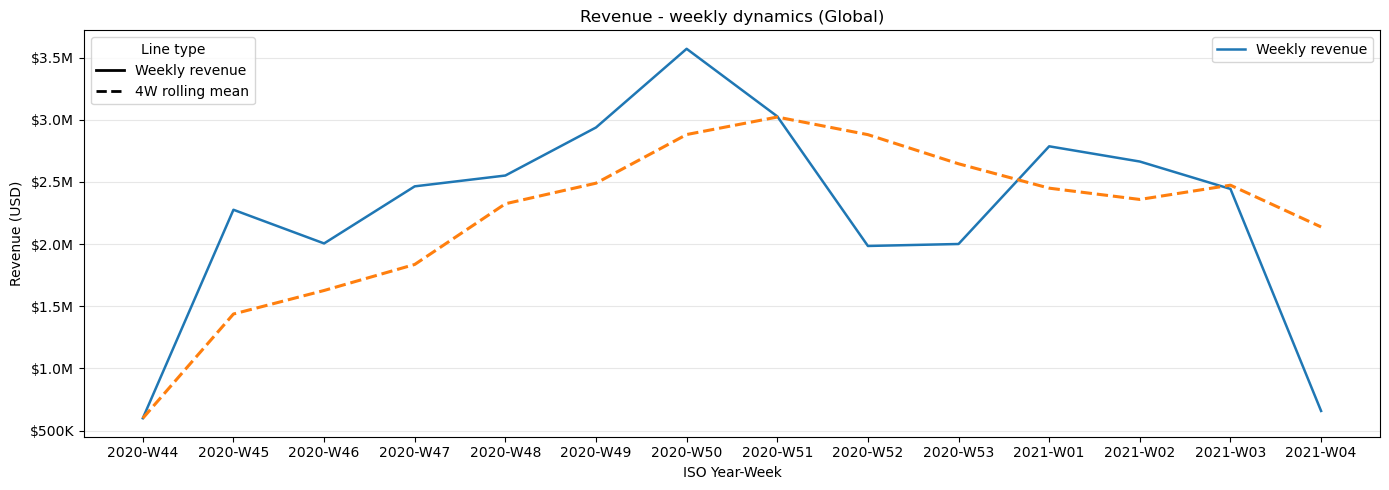

In [92]:
# 5.3 Global weekly dynamics (rolling trend)

plot_weekly_ts_iso(
    weekly_df=weekly_global,
    week_start_col="week_start",
    value_col="weekly_revenue",
    title="Revenue - weekly dynamics (Global)",
    group_col=None,
    top_n=None,
    rolling_weeks=4,
    legend_loc="best",
    max_xticks=14,
    rotate_xticks=0
)

**1) Is there sales seasonality?**
- Yes - short-term seasonality / an event effect (holiday period) is visible. There is a clear rise up to a peak in 2020-W50, then a drop in W52–W53, followed by recovery in 2021-W01…W03.
- **Interpretation risk:** the data window is short (≈ 3 months), so this is **not “annual” seasonality** but rather a holiday/promo period plus a post-holiday decline.

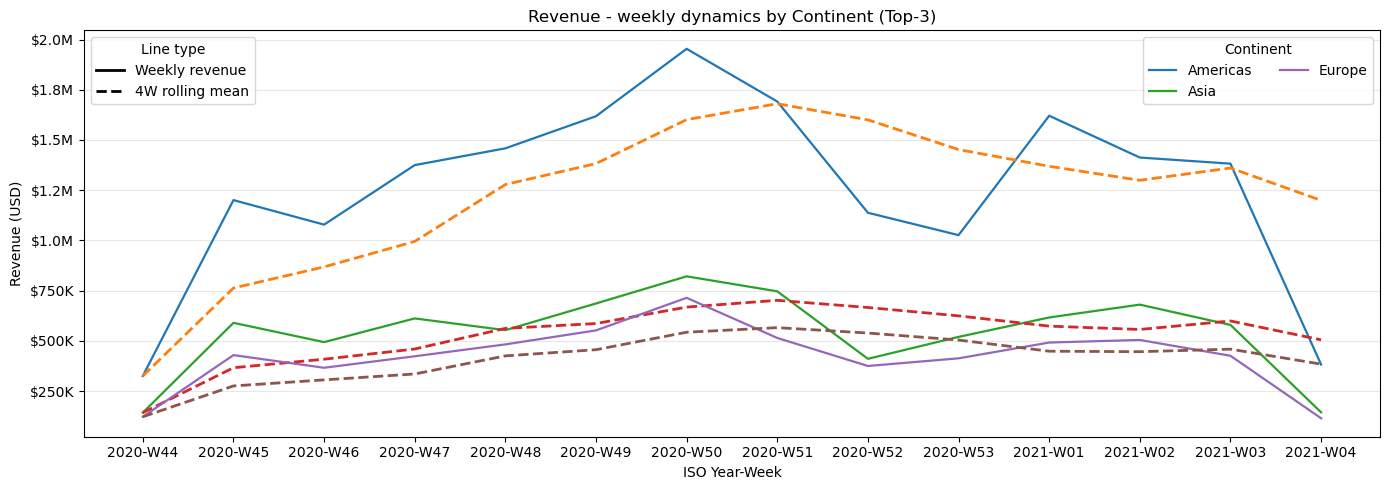

In [93]:
# 5.4 Weekly dynamics by Continent (Top-3)

if "continent" in purchase_df.columns:
    weekly_by_continent = (
        purchase_df
        .groupby(["week_start", "continent"], as_index=False)
        .agg(weekly_revenue=("product_price", "sum"))
        .sort_values(["continent", "week_start"])
    )

    plot_weekly_ts_iso(
        weekly_df=weekly_by_continent,
        week_start_col="week_start",
        value_col="weekly_revenue",
        title="Revenue - weekly dynamics by Continent (Top-3)",
        group_col="continent",
        top_n=3,
        rolling_weeks=4,
        legend_loc="best",
        max_xticks=14,
        rotate_xticks=0
    )
else:
    print("\n[Skip 5.4] Column 'continent' not found.")

**2) Dynamics in Americas, Asia, Europe**
- Americas is the main driver. The profile almost mirrors the global one: peak at W50, decline at W52–W53, rebound at W01–W03. It has the largest contribution every week.
- Asia is second by contribution. It also grows through W50–W51, then declines toward year-end and partially recovers at the start of 2021.
- Europe is third. The “flattest” trajectory: moderate growth to W50, then a decline; fluctuations are smaller than in the Americas.

**Conclusion: changes in global revenue are primarily explained by the Americas, while Asia/Europe amplify the trend but do not set it.**

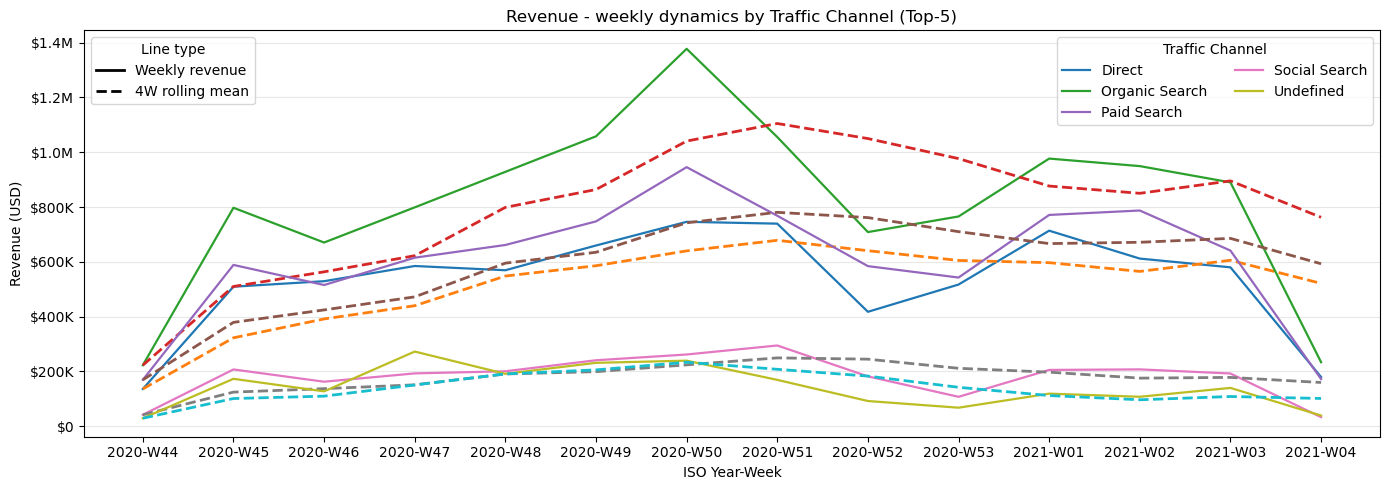

In [94]:
# 5.5 Weekly dynamics by Traffic Channel (Top-5)

if "traffic_channel" in purchase_df.columns:
    weekly_by_channel = (
        purchase_df
        .groupby(["week_start", "traffic_channel"], as_index=False)
        .agg(weekly_revenue=("product_price", "sum"))
        .sort_values(["traffic_channel", "week_start"])
    )

    plot_weekly_ts_iso(
        weekly_df=weekly_by_channel,
        week_start_col="week_start",
        value_col="weekly_revenue",
        title="Revenue - weekly dynamics by Traffic Channel (Top-5)",
        group_col="traffic_channel",
        top_n=5,
        rolling_weeks=4,
        legend_loc="best",
        max_xticks=14,
        rotate_xticks=0
    )
else:
    print("\n[Skip 5.5] Column 'traffic_channel' not found.")

**3) Dynamics by traffic channels (Top-5)**
- Organic Search is the largest and most volatile: a sharp peak at W50 followed by a decline; it is the key channel that “moves” the overall dynamics.
- Paid Search is a stable #2: growth to W50–W51, then a smooth decline/plateau, and partial recovery at the start of 2021.
- Direct has a noticeable contribution but without peaks as sharp as Organic; the W52–W53 decline is also present.
- Social Search and Undefined are low-level with weaker trends; their impact on the global curve is minimal.

**Conclusion: most week-to-week changes are explained by Organic + Paid + Direct; other channels form the “long tail”.**

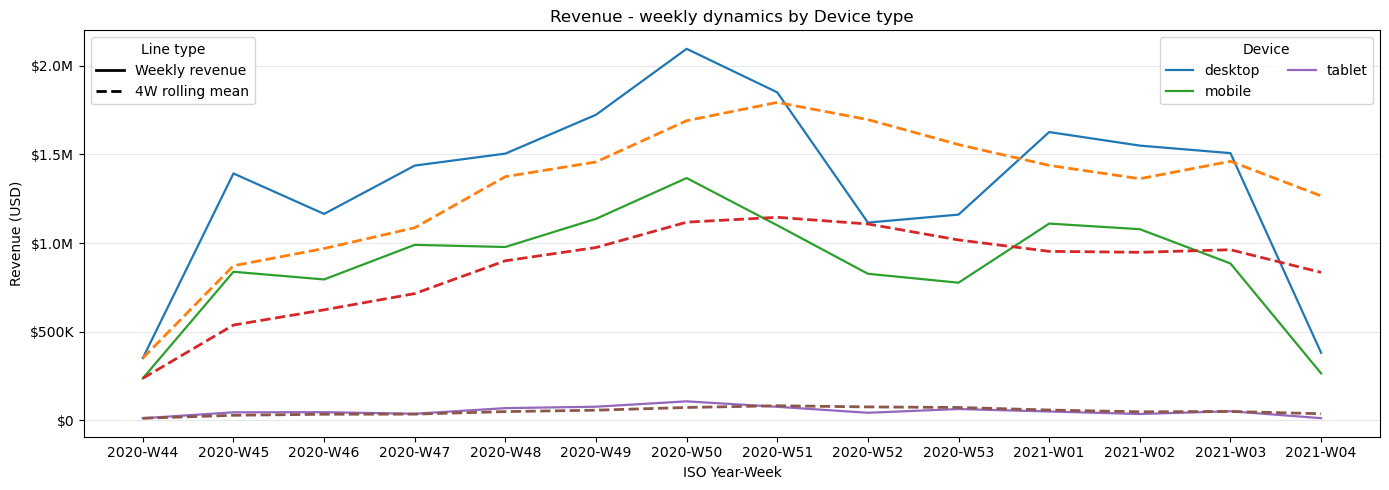

In [95]:
# 5.6 Weekly dynamics by Device type

if "device" in purchase_df.columns:
    weekly_by_device = (
        purchase_df
        .groupby(["week_start", "device"], as_index=False)
        .agg(weekly_revenue=("product_price", "sum"))
        .sort_values(["device", "week_start"])
    )

    # If device has too many unique values, limit to top_n=5 (optional)
    plot_weekly_ts_iso(
        weekly_df=weekly_by_device,
        week_start_col="week_start",
        value_col="weekly_revenue",
        title="Revenue - weekly dynamics by Device type",
        group_col="device",
        top_n=None,            # set to 5 if too many device types
        rolling_weeks=4,
        legend_loc="best",
        max_xticks=14,
        rotate_xticks=0
    )
else:
    print("\n[Skip 5.6] Column 'device' not found.")

**4) Dynamics by device type**
- Desktop generates the most revenue and shows a strong seasonal wave: peak at W50, decline at W52–W53, rebound at W01–W03.
- Mobile is second by contribution; the trend is similar to desktop but at lower levels.
- Tablet is marginal and barely affects the overall picture.

**Conclusion: sales dynamics are mainly driven by desktop + mobile, with desktop being the key carrier of “peakiness”.**

# 6. Pivot tables

In [96]:
import pandas as pd

# Assumption: df already loaded
work_df = df.copy()

# Ensure datetime (if needed later)
if "order_date" in work_df.columns:
    work_df["order_date"] = pd.to_datetime(work_df["order_date"], errors="coerce")

# Define purchase lines (for revenue pivots)
if "has_purchase" in work_df.columns:
    purchase_df = work_df[work_df["has_purchase"] == True].copy()
else:
    purchase_df = work_df[work_df["product_price"].notna()].copy()

In [97]:
# 6.1 Pivot: Sessions count by Traffic Channel x Device
# (Exclude unknowns in either field)

sessions_base = work_df.dropna(subset=["ga_session_id", "traffic_channel", "device"]).copy()
sessions_base = sessions_base[
    (sessions_base["traffic_channel"].astype(str).str.strip() != "") &
    (sessions_base["device"].astype(str).str.strip() != "")
].copy()

pivot_sessions_channel_device = (
    sessions_base
    .groupby(["traffic_channel", "device"], as_index=False)
    .agg(sessions_count=("ga_session_id", "nunique"))
    .pivot(index="traffic_channel", columns="device", values="sessions_count")
    .fillna(0)
    .astype(int)
)

# Add totals (optional but useful)
pivot_sessions_channel_device["Total"] = pivot_sessions_channel_device.sum(axis=1)
pivot_sessions_channel_device.loc["Total"] = pivot_sessions_channel_device.sum(axis=0)

display(pivot_sessions_channel_device)

device,desktop,mobile,tablet,Total
traffic_channel,,,,
Direct,47825,31745,1812,81382
Organic Search,72622,49014,2789,124425
Paid Search,55167,37034,2140,94341
Social Search,16288,10988,638,27914
Undefined,12527,8486,470,21483
Total,204429,137267,7849,349545


In [98]:
# 6.2 Pivot: Revenue by Product Category (Top-10) x Country (Top-5)
# - Top-10 categories by global revenue
# - Top-5 countries by global revenue

purch_geo = purchase_df.dropna(subset=["product_category", "country", "product_price"]).copy()

# top-10 categories (global)
top10_categories = (
    purch_geo.groupby("product_category", as_index=False)
    .agg(total_revenue=("product_price", "sum"))
    .sort_values("total_revenue", ascending=False)
    .head(10)["product_category"]
    .tolist()
)

# top-5 countries (global)
top5_countries = (
    purch_geo.groupby("country", as_index=False)
    .agg(total_revenue=("product_price", "sum"))
    .sort_values("total_revenue", ascending=False)
    .head(5)["country"]
    .tolist()
)

purch_geo_top = purch_geo[
    purch_geo["product_category"].isin(top10_categories) &
    purch_geo["country"].isin(top5_countries)
].copy()

pivot_revenue_cat_country = (
    purch_geo_top
    .groupby(["product_category", "country"], as_index=False)
    .agg(total_revenue=("product_price", "sum"))
    .pivot(index="product_category", columns="country", values="total_revenue")
    .fillna(0)
)

# Add totals (optional)
pivot_revenue_cat_country["Total"] = pivot_revenue_cat_country.sum(axis=1)
pivot_revenue_cat_country = pivot_revenue_cat_country.sort_values("Total", ascending=False)
pivot_revenue_cat_country.loc["Total"] = pivot_revenue_cat_country.sum(axis=0)

display(pivot_revenue_cat_country)

country,Canada,France,India,United Kingdom,United States,Total
product_category,,,,,,
Sofas & armchairs,"692,427.50","187,735.00","788,430.00","234,812.00","3,707,144.50","5,610,549.00"
Chairs,"417,740.80","134,029.40","544,309.20","188,519.40","2,619,773.80","3,904,372.60"
Beds,"354,772.00","116,414.00","358,319.50","133,816.00","2,213,058.00","3,176,379.50"
Bookcases & shelving units,"278,981.90","73,830.00","364,507.40","113,987.60","1,567,606.90","2,398,913.80"
Cabinets & cupboards,"181,802.00","59,101.50","191,888.00","71,684.50","994,545.50","1,499,021.50"
Outdoor furniture,"185,322.80","40,486.40","162,289.40","57,002.40","929,245.20","1,374,346.20"
Tables & desks,"132,678.00","42,299.00","186,157.50","49,374.00","777,865.00","1,188,373.50"
Chests of drawers & drawer units,"71,952.00","21,544.50","73,111.00","36,784.00","382,388.00","585,779.50"
Bar furniture,"51,724.00","11,199.00","57,657.00","22,103.00","330,805.00","473,488.00"


In [99]:
# 6.3 Extra Pivot: Conversion proxy by Traffic Channel x Device
# conversion_rate_proxy = purchase_sessions / total_sessions

# sessions by channel x device
sess_cd = (
    sessions_base
    .groupby(["traffic_channel", "device"], as_index=False)
    .agg(sessions=("ga_session_id", "nunique"))
)

# purchase sessions by channel x device
purch_cd = purchase_df.dropna(subset=["ga_session_id", "traffic_channel", "device"]).copy()
purch_cd = purch_cd[
    (purch_cd["traffic_channel"].astype(str).str.strip() != "") &
    (purch_cd["device"].astype(str).str.strip() != "")
].copy()

purch_sess_cd = (
    purch_cd
    .groupby(["traffic_channel", "device"], as_index=False)
    .agg(purchase_sessions=("ga_session_id", "nunique"))
)

conv_cd = sess_cd.merge(purch_sess_cd, on=["traffic_channel", "device"], how="left")
conv_cd["purchase_sessions"] = conv_cd["purchase_sessions"].fillna(0)
conv_cd["conversion_rate_proxy"] = conv_cd["purchase_sessions"] / conv_cd["sessions"]

pivot_conv_channel_device = (
    conv_cd.pivot(index="traffic_channel", columns="device", values="conversion_rate_proxy")
)

display(pivot_conv_channel_device)

device,desktop,mobile,tablet
traffic_channel,,,
Direct,0.10,0.09,0.09
Organic Search,0.10,0.09,0.09
Paid Search,0.10,0.10,0.10
Social Search,0.10,0.10,0.09
Undefined,0.09,0.10,0.09


In [100]:
# 6.4 Extra Pivot: AOV proxy by Country (Top-5) x Traffic Channel (Top-5)
# AOV proxy = revenue / purchase_sessions

purch_aov = purchase_df.dropna(subset=["country", "traffic_channel", "product_price", "ga_session_id"]).copy()

top5_countries_rev = (
    purch_aov.groupby("country", as_index=False)
    .agg(total_revenue=("product_price", "sum"))
    .sort_values("total_revenue", ascending=False)
    .head(5)["country"].tolist()
)

top5_channels_rev = (
    purch_aov.groupby("traffic_channel", as_index=False)
    .agg(total_revenue=("product_price", "sum"))
    .sort_values("total_revenue", ascending=False)
    .head(5)["traffic_channel"].tolist()
)

purch_aov = purch_aov[
    purch_aov["country"].isin(top5_countries_rev) &
    purch_aov["traffic_channel"].isin(top5_channels_rev)
].copy()

aov_by_country_channel = (
    purch_aov
    .groupby(["country", "traffic_channel"], as_index=False)
    .agg(
        revenue=("product_price", "sum"),
        purchase_sessions=("ga_session_id", "nunique")
    )
)

aov_by_country_channel["aov_proxy"] = aov_by_country_channel["revenue"] / aov_by_country_channel["purchase_sessions"]

pivot_aov_country_channel = (
    aov_by_country_channel
    .pivot(index="country", columns="traffic_channel", values="aov_proxy")
    .fillna(0)
)

display(pivot_aov_country_channel)

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
country,,,,,
Canada,993.17,989.49,933.47,771.65,890.62
France,"1,085.25","1,056.71","1,007.44","1,038.08","1,057.69"
India,941.20,895.56,925.18,937.84,"1,062.54"
United Kingdom,863.26,940.47,964.20,710.08,916.57
United States,981.20,956.97,909.42,935.30,993.04


# 7. Statistical analysis of relationships (correlations)

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats



# Helpers

def _ensure_datetime(df_: pd.DataFrame, col: str) -> pd.DataFrame:
    out = df_.copy()
    out[col] = pd.to_datetime(out[col], errors="coerce")
    return out.dropna(subset=[col])


def build_daily_sessions_revenue(df: pd.DataFrame) -> pd.DataFrame:
    """
    Daily sessions: distinct ga_session_id per date (ALL sessions).
    Daily revenue: sum(product_price) per date (purchase lines only).
    Returns: date, sessions, revenue
    """
    base = _ensure_datetime(df, "order_date").copy()
    base["date"] = base["order_date"].dt.date

    # Sessions (all)
    daily_sessions = (
        base.dropna(subset=["ga_session_id"])
        .groupby("date", as_index=False)
        .agg(sessions=("ga_session_id", "nunique"))
    )

    # Revenue (purchase lines)
    purch = base[base["product_price"].notna()].copy()
    daily_revenue = (
        purch.groupby("date", as_index=False)
        .agg(revenue=("product_price", "sum"))
    )

    # Merge & fill
    daily = daily_sessions.merge(daily_revenue, on="date", how="left")
    daily["revenue"] = daily["revenue"].fillna(0)

    # Ensure full date range (optional, but good for consistent TS)
    dmin, dmax = daily["date"].min(), daily["date"].max()
    full = pd.DataFrame({"date": pd.date_range(dmin, dmax, freq="D").date})
    daily = full.merge(daily, on="date", how="left")
    daily["sessions"] = daily["sessions"].fillna(0).astype(int)
    daily["revenue"] = daily["revenue"].fillna(0.0)

    return daily


def corr_with_pvalue(x: pd.Series, y: pd.Series, method: str = "pearson"):
    """
    Returns (r, pvalue). Supports pearson/spearman.
    """
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)

    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]

    if method == "pearson":
        r, p = stats.pearsonr(x, y)
    elif method == "spearman":
        r, p = stats.spearmanr(x, y)
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")
    return r, p


def plot_scatter_relationship(daily: pd.DataFrame, xcol: str, ycol: str, title: str):
    """
    Scatter + simple linear fit line (for visual intuition).
    """
    x = daily[xcol].astype(float).values
    y = daily[ycol].astype(float).values

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.6)

    # Fit line (OLS)
    if np.unique(x).size >= 2:
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ys = m * xs + b
        plt.plot(xs, ys, linewidth=2)

    plt.title(title)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.grid(True, axis="both", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_corr_heatmap(corr_df: pd.DataFrame, title: str):
    """
    Matplotlib heatmap for correlation matrix.
    """
    mat = corr_df.values
    labels = corr_df.columns.tolist()

    plt.figure(figsize=(8, 6))
    im = plt.imshow(
        mat, 
        aspect="auto",
        cmap="bone",
        vmin=-1,
        vmax=1)
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)

    # Annotate
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=9)

    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def bonferroni_adjust(pvals: list[float]) -> list[float]:
    """
    Conservative multiple-testing correction.
    """
    m = len(pvals)
    return [min(p * m, 1.0) for p in pvals]

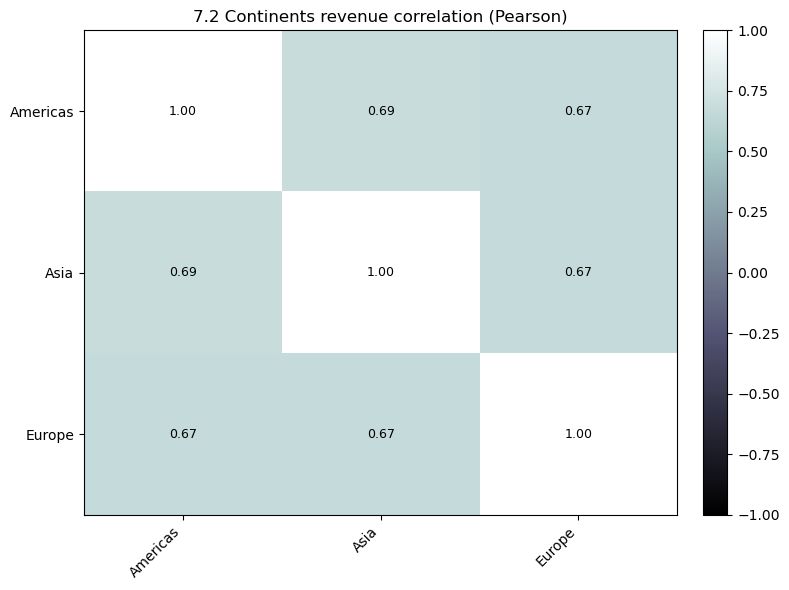


7.2 Pairwise continent correlations (Pearson) + Bonferroni-adjusted p-values
Americas vs Asia: r=0.692, p=8.004e-14, p_adj=2.401e-13
Americas vs Europe: r=0.670, p=9.911e-13, p_adj=2.973e-12
Asia vs Europe: r=0.668, p=1.191e-12, p_adj=3.573e-12


In [102]:
# 7.2 Correlation of sales between top-3 continents (daily)

base = _ensure_datetime(df, "order_date").copy()
base["date"] = base["order_date"].dt.date

purch = base[base["product_price"].notna()].copy()
purch["continent"] = purch["continent"].fillna("Unknown").astype(str)

# Top-3 continents by revenue
top3_cont = (
    purch.groupby("continent", as_index=False)
    .agg(total_revenue=("product_price", "sum"))
    .sort_values("total_revenue", ascending=False)
    .head(3)["continent"].tolist()
)

cont_daily = (
    purch[purch["continent"].isin(top3_cont)]
    .groupby(["date", "continent"], as_index=False)
    .agg(revenue=("product_price", "sum"))
)

cont_wide = (
    cont_daily.pivot(index="date", columns="continent", values="revenue")
    .fillna(0.0)
    .sort_index()
)

# Correlation matrix
cont_corr = cont_wide.corr(method="pearson")
plot_corr_heatmap(cont_corr, "7.2 Continents revenue correlation (Pearson)")

# Pairwise p-values + Bonferroni correction
cont_names = cont_wide.columns.tolist()
pvals = []
pairs = []
for i in range(len(cont_names)):
    for j in range(i + 1, len(cont_names)):
        a, b = cont_names[i], cont_names[j]
        r, p = corr_with_pvalue(cont_wide[a], cont_wide[b], method="pearson")
        pairs.append((a, b, r, p))
        pvals.append(p)

pvals_adj = bonferroni_adjust(pvals)

print("\n7.2 Pairwise continent correlations (Pearson) + Bonferroni-adjusted p-values")
for (a, b, r, p), padj in zip(pairs, pvals_adj):
    print(f"{a} vs {b}: r={r:.3f}, p={p:.4g}, p_adj={padj:.4g}")

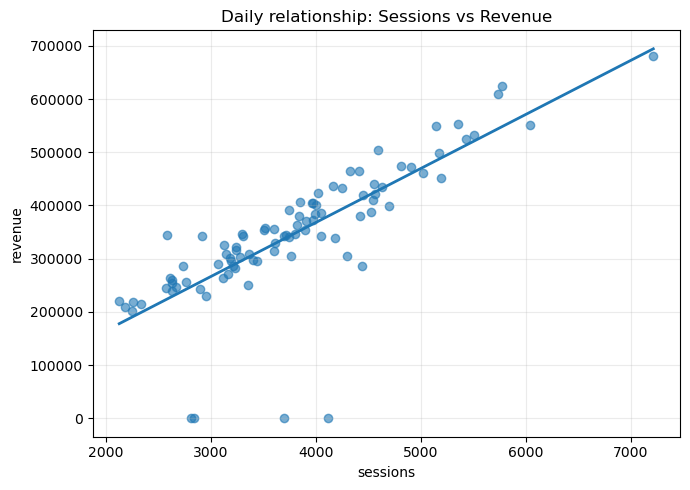

7.1 Sessions vs Revenue (daily)
Pearson r = 0.791, p-value = 6.484e-21
Spearman ρ = 0.865, p-value = 9.756e-29


In [103]:
# 7.1 Sessions vs Revenue (daily) + correlation + p-value

daily = build_daily_sessions_revenue(df)

# Visual relationship
plot_scatter_relationship(
    daily=daily,
    xcol="sessions",
    ycol="revenue",
    title="Daily relationship: Sessions vs Revenue"
)

# Correlations
pearson_r, pearson_p = corr_with_pvalue(daily["sessions"], daily["revenue"], method="pearson")
spearman_r, spearman_p = corr_with_pvalue(daily["sessions"], daily["revenue"], method="spearman")

print("7.1 Sessions vs Revenue (daily)")
print(f"Pearson r = {pearson_r:.3f}, p-value = {pearson_p:.4g}")
print(f"Spearman ρ = {spearman_r:.3f}, p-value = {spearman_p:.4g}")

**Interpretation:**
- The relationship is strong and positive: Pearson r = 0.791, Spearman ρ = 0.865 → more sessions per day usually means higher revenue.
- Statistically significant: p-value ≪ 0.001 for both metrics → the correlation is unlikely to be random within this sample.
- Traffic volume is a key revenue driver, but the scatter indicates revenue is also influenced by traffic quality / channel mix / average check.

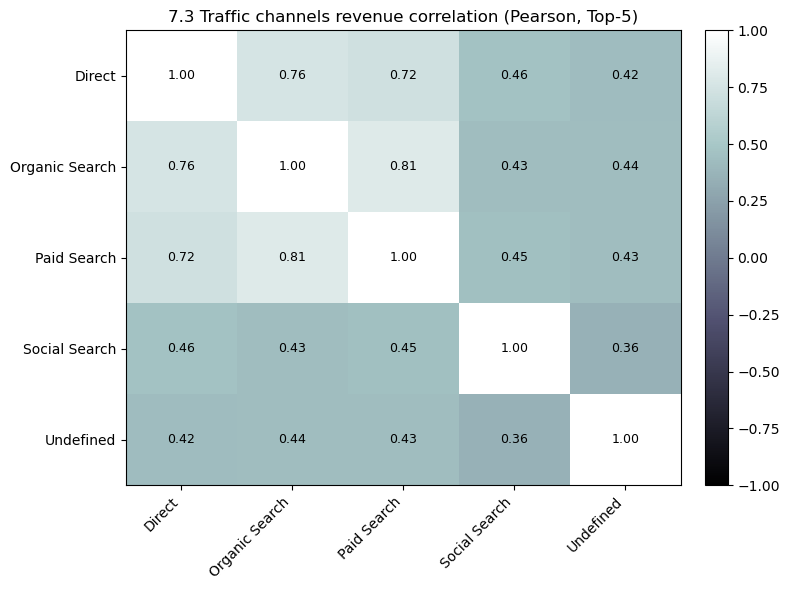


7.3 Pairwise channel correlations (Pearson) + Bonferroni-adjusted p-values
Direct vs Organic Search: r=0.760, p=9.108e-18, p_adj=9.108e-17
Direct vs Paid Search: r=0.724, p=1.513e-15, p_adj=1.513e-14
Direct vs Social Search: r=0.462, p=5.901e-06, p_adj=5.901e-05
Direct vs Undefined: r=0.424, p=3.839e-05, p_adj=0.0003839
Organic Search vs Paid Search: r=0.808, p=1.756e-21, p_adj=1.756e-20
Organic Search vs Social Search: r=0.434, p=2.348e-05, p_adj=0.0002348
Organic Search vs Undefined: r=0.435, p=2.238e-05, p_adj=0.0002238
Paid Search vs Social Search: r=0.452, p=9.696e-06, p_adj=9.696e-05
Paid Search vs Undefined: r=0.430, p=2.897e-05, p_adj=0.0002897
Social Search vs Undefined: r=0.359, p=0.0005853, p_adj=0.005853


In [104]:
# 7.3 Correlation of sales between traffic channels (top-5) (daily)

purch["traffic_channel"] = purch["traffic_channel"].fillna("Unknown").astype(str)

top5_ch = (
    purch.groupby("traffic_channel", as_index=False)
    .agg(total_revenue=("product_price", "sum"))
    .sort_values("total_revenue", ascending=False)
    .head(5)["traffic_channel"].tolist()
)

ch_daily = (
    purch[purch["traffic_channel"].isin(top5_ch)]
    .groupby(["date", "traffic_channel"], as_index=False)
    .agg(revenue=("product_price", "sum"))
)

ch_wide = (
    ch_daily.pivot(index="date", columns="traffic_channel", values="revenue")
    .fillna(0.0)
    .sort_index()
)

ch_corr = ch_wide.corr(method="pearson")
plot_corr_heatmap(ch_corr, "7.3 Traffic channels revenue correlation (Pearson, Top-5)")

# Pairwise tests + correction
ch_names = ch_wide.columns.tolist()
pvals, pairs = [], []
for i in range(len(ch_names)):
    for j in range(i + 1, len(ch_names)):
        a, b = ch_names[i], ch_names[j]
        r, p = corr_with_pvalue(ch_wide[a], ch_wide[b], method="pearson")
        pairs.append((a, b, r, p))
        pvals.append(p)

pvals_adj = bonferroni_adjust(pvals)

print("\n7.3 Pairwise channel correlations (Pearson) + Bonferroni-adjusted p-values")
for (a, b, r, p), padj in zip(pairs, pvals_adj):
    print(f"{a} vs {b}: r={r:.3f}, p={p:.4g}, p_adj={padj:.4g}")

**Interpretation**
Strong synchrony among the “core” channels:
- Organic ↔ Paid 0.81, Direct ↔ Organic 0.76, Direct ↔ Paid 0.72 (significant).
- Weaker links with Social/Undefined: ~0.36–0.46.

**Overall:** channels often scale simultaneously, but Social/Undefined behave more autonomously or noisily.

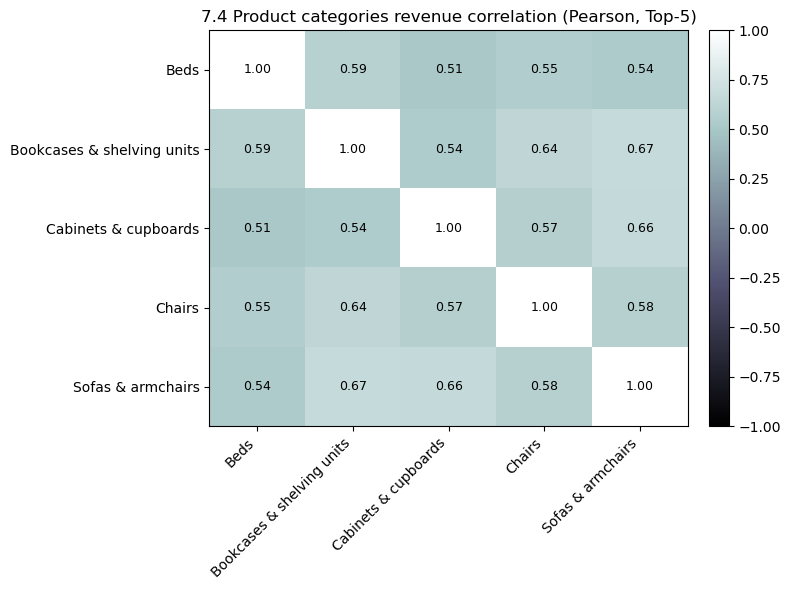


7.4 Pairwise category correlations (Pearson) + Bonferroni-adjusted p-values
Beds vs Bookcases & shelving units: r=0.593, p=1.155e-09, p_adj=1.155e-08
Beds vs Cabinets & cupboards: r=0.515, p=2.911e-07, p_adj=2.911e-06
Beds vs Chairs: r=0.554, p=2.079e-08, p_adj=2.079e-07
Beds vs Sofas & armchairs: r=0.535, p=7.687e-08, p_adj=7.687e-07
Bookcases & shelving units vs Cabinets & cupboards: r=0.539, p=5.867e-08, p_adj=5.867e-07
Bookcases & shelving units vs Chairs: r=0.637, p=2.505e-11, p_adj=2.505e-10
Bookcases & shelving units vs Sofas & armchairs: r=0.666, p=1.407e-12, p_adj=1.407e-11
Cabinets & cupboards vs Chairs: r=0.573, p=5.466e-09, p_adj=5.466e-08
Cabinets & cupboards vs Sofas & armchairs: r=0.658, p=3.415e-12, p_adj=3.415e-11
Chairs vs Sofas & armchairs: r=0.578, p=3.639e-09, p_adj=3.639e-08


In [105]:
# 7.4 Correlation of sales between top-5 product categories (daily)

purch["product_category"] = purch["product_category"].fillna("Unknown").astype(str)

top5_cat = (
    purch.groupby("product_category", as_index=False)
    .agg(total_revenue=("product_price", "sum"))
    .sort_values("total_revenue", ascending=False)
    .head(5)["product_category"].tolist()
)

cat_daily = (
    purch[purch["product_category"].isin(top5_cat)]
    .groupby(["date", "product_category"], as_index=False)
    .agg(revenue=("product_price", "sum"))
)

cat_wide = (
    cat_daily.pivot(index="date", columns="product_category", values="revenue")
    .fillna(0.0)
    .sort_index()
)

cat_corr = cat_wide.corr(method="pearson")
plot_corr_heatmap(cat_corr, "7.4 Product categories revenue correlation (Pearson, Top-5)")

# Pairwise tests + correction
cat_names = cat_wide.columns.tolist()
pvals, pairs = [], []
for i in range(len(cat_names)):
    for j in range(i + 1, len(cat_names)):
        a, b = cat_names[i], cat_names[j]
        r, p = corr_with_pvalue(cat_wide[a], cat_wide[b], method="pearson")
        pairs.append((a, b, r, p))
        pvals.append(p)

pvals_adj = bonferroni_adjust(pvals)

print("\n7.4 Pairwise category correlations (Pearson) + Bonferroni-adjusted p-values")
for (a, b, r, p), padj in zip(pairs, pvals_adj):
    print(f"{a} vs {b}: r={r:.3f}, p={p:.4g}, p_adj={padj:.4g}")

**Interpretation**
Mostly moderate positive correlations: 0.51–0.67, significant (small p_adj).

**Overall:** categories rise/fall together → general demand / seasonality / promotions dominate, rather than isolated “category-specific” factors.

In [106]:
# 7.5 Lag analysis: do sessions lead revenue? (shift sessions by 1–7 days)

print("\n7.5 Lag correlation: Sessions(t-k) vs Revenue(t)")
lags = range(0, 8)
lag_results = []
for k in lags:
    x = daily["sessions"].shift(k)
    y = daily["revenue"]
    r, p = corr_with_pvalue(x, y, method="pearson")
    lag_results.append((k, r, p))

lag_df = pd.DataFrame(lag_results, columns=["lag_days", "pearson_r", "p_value"])
display(lag_df)



7.5 Lag correlation: Sessions(t-k) vs Revenue(t)


,lag_days,pearson_r,p_value
0,0,0.79,0.00
1,1,0.55,0.00
2,2,0.24,0.02
3,3,0.04,0.69
4,4,-0.02,0.85
5,5,0.12,0.26
6,6,0.35,0.00
7,7,0.46,0.00


**Interpretation**
- Most sales happen on the same day as the traffic (lag 0 → highest r = 0.79).
- The effect “decays” over 1–2 days: lag 1 (~0.55), lag 2 (~0.24), then weak/unstable (lag 3–5 not significant).
- There is a weekly component: lag 6–7 increases again (~0.35–0.46, significant) → a likely weekly pattern (behavioral cycle / day-of-week effects).

**Overall business takeaways:**
- Traffic is the key short-term driver of revenue (the same-day effect is the strongest).
- There is a regular weekly pattern (lag 7) → planning and management should account for day-of-week differences.
- Revenue dynamics are mostly driven by shared factors rather than local ones: synchrony across continents, channels, and categories is high.
- Social/Undefined are less predictable relative to core channels → either a different demand mechanism or weaker data/attribution.

**Recommendations:**
1. Day-of-week marketing planning: align budgets/promotions/CRM activities with peak weekdays; measure the DoW effect explicitly.
2. Operational revenue forecasting: a baseline 0–1 day ahead model can use `sessions_today` as the main predictor + fixed day-of-week effects.
3. Decompose “what drives revenue”: break revenue into Sessions × Conversion × AOV and run correlations/regressions on components (because a sessions↔revenue correlation does not explain causality).
4. Channels: for Organic/Paid/Direct, analyze synchrony with budgets/campaigns (shared demand vs controllable effect); for Social/Undefined, validate traffic quality and classification (UTM, source/medium, “Undefined”, “Other/raw”).
5. Categories: if categories move together, plan promos and merchandising as a “portfolio” rather than isolated verticals; look for exceptions via anomalies / lowest-correlation categories.

**Important:** correlation indicates association, not causality.
Causal conclusions require experiments/causal approaches (A/B tests, geo-experiments, MMM / Marketing Mix Modeling, etc.).

# 8. Statistical differences

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Optional: proportions z-test (if statsmodels installed)
try:
    from statsmodels.stats.proportion import proportions_ztest
    _HAS_SM = True
except Exception:
    _HAS_SM = False

# -------------------------
# Helpers
# -------------------------
def fmt_p(p):
    if p is None or pd.isna(p):
        return "NA"
    return f"{p:.3g}" if p >= 0.001 else f"{p:.2e}"

def print_conclusion(test_name, p, alpha=0.05):
    verdict = "STATISTICALLY significant difference" if (p is not None and p < alpha) else "No statistically significant difference"
    print(f"{test_name}: p-value = {fmt_p(p)} → {verdict} (alpha={alpha})")

def cliff_delta(x, y):
    """Cliff's delta for two independent samples (robust effect size)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)
    return (gt - lt) / (len(x) * len(y))

def cohens_h(p1, p2):
    """Effect size for proportions."""
    p1 = np.clip(p1, 1e-12, 1 - 1e-12)
    p2 = np.clip(p2, 1e-12, 1 - 1e-12)
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))


# 8.0 Build session_sales (robust definition)

# Assumes df is your enriched (or master) dataset.

work_df = df.copy()
work_df["order_date"] = pd.to_datetime(work_df["order_date"], errors="coerce")

# Organic mapping (normalized)
ORGANIC_LABELS = {"organic search", "organic", "(organic)"}
work_df["traffic_channel_norm"] = (
    work_df["traffic_channel"]
    .astype(str)
    .str.strip()
    .str.lower()
)
work_df["is_organic"] = work_df["traffic_channel_norm"].isin(ORGANIC_LABELS)

# Purchase definition
if "has_purchase" in work_df.columns:
    purchase_lines = work_df[work_df["has_purchase"] == True].copy()
else:
    purchase_lines = work_df[work_df["product_price"].notna()].copy()

purchase_lines = purchase_lines.dropna(subset=["ga_session_id", "order_date"])

# Session-level aggregation (even if 1 session = 1 item, still safe)
session_sales = (
    purchase_lines
    .groupby("ga_session_id", as_index=False)
    .agg(
        order_date=("order_date", "min"),
        session_revenue=("product_price", "sum"),
        user_id=("user_id", "first"),
        continent=("continent", "first"),
        traffic_channel=("traffic_channel", "first"),
        traffic_channel_norm=("traffic_channel_norm", "first"),
        is_organic=("is_organic", "max"),
    )
)

session_sales["date"] = session_sales["order_date"].dt.date
session_sales["is_registered"] = session_sales["user_id"].notna()

print("Session-level purchase dataset shape:", session_sales.shape)
print("Unique purchase sessions (orders proxy):", session_sales["ga_session_id"].nunique())
print("Date range:", session_sales["order_date"].min(), "→", session_sales["order_date"].max())



Session-level purchase dataset shape: (33538, 10)
Unique purchase sessions (orders proxy): 33538
Date range: 2020-11-01 00:00:00 → 2021-01-27 00:00:00


Days: 88
Registered (mean/median): 29346.801136363636 / 28048.0
Unregistered (mean/median): 333968.325 / 316724.25


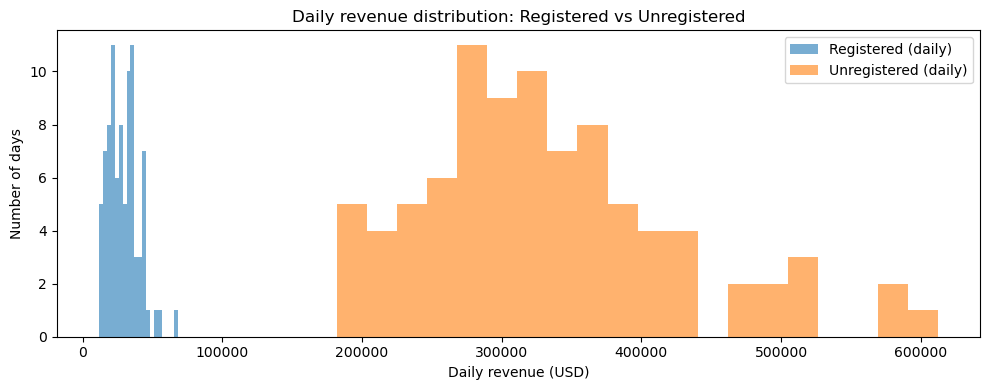

Shapiro p (registered)   = 0.0073
Shapiro p (unregistered) = 0.00262
Mann–Whitney U: U=0, p=2.22e-30
Cliff's delta (effect size) = -1.000
8.1 Mann–Whitney U (daily revenue): p-value = 2.22e-30 → STATISTICALLY significant difference (alpha=0.05)


In [108]:
# 8.1 Daily revenue: Registered vs Unregistered

# Compare DAILY total revenue between groups (days as observations).
# This avoids inflating N by line-items.

daily_rev = (
    session_sales
    .groupby(["date", "is_registered"], as_index=False)
    .agg(daily_revenue=("session_revenue", "sum"),
         daily_orders=("ga_session_id", "nunique"))
)

daily_pivot = (
    daily_rev
    .pivot(index="date", columns="is_registered", values="daily_revenue")
    .rename(columns={False: "unregistered", True: "registered"})
    .fillna(0.0)
    .sort_index()
)

x_reg = daily_pivot["registered"].values
x_unreg = daily_pivot["unregistered"].values

print("Days:", len(daily_pivot))
print("Registered (mean/median):", np.mean(x_reg), "/", np.median(x_reg))
print("Unregistered (mean/median):", np.mean(x_unreg), "/", np.median(x_unreg))

# Distribution view
plt.figure(figsize=(10, 4))
plt.hist(x_reg, bins=20, alpha=0.6, label="Registered (daily)")
plt.hist(x_unreg, bins=20, alpha=0.6, label="Unregistered (daily)")
plt.title("Daily revenue distribution: Registered vs Unregistered")
plt.xlabel("Daily revenue (USD)")
plt.ylabel("Number of days")
plt.legend()
plt.tight_layout()
plt.show()

# Normality check (Shapiro) on DAILY values (small-medium N ok). If N huge, Shapiro is too sensitive.
# Here: we use robust Mann–Whitney by default for skewed revenue.
if len(x_reg) >= 3 and len(x_reg) <= 5000:
    p_sh_reg = stats.shapiro(x_reg)[1]
else:
    p_sh_reg = np.nan

if len(x_unreg) >= 3 and len(x_unreg) <= 5000:
    p_sh_unreg = stats.shapiro(x_unreg)[1]
else:
    p_sh_unreg = np.nan

print(f"Shapiro p (registered)   = {fmt_p(p_sh_reg)}")
print(f"Shapiro p (unregistered) = {fmt_p(p_sh_unreg)}")

u_stat, p_u = stats.mannwhitneyu(x_reg, x_unreg, alternative="two-sided")
delta = cliff_delta(x_reg, x_unreg)

print(f"Mann–Whitney U: U={u_stat:.0f}, p={fmt_p(p_u)}")
print(f"Cliff's delta (effect size) = {delta:.3f}")
print_conclusion("8.1 Mann–Whitney U (daily revenue)", p_u)

**Interpretation of results:**
- Mean vs median: the data is highly skewed; unregistered users generate an order of magnitude more money per day.
- Shapiro–Wilk test: p < 0.05 (0.0073 and 0.0026) → distributions are not normal, so we use a non-parametric Mann–Whitney test.
- Mann–Whitney U test: the difference between groups is statistically significant (p = 2.22e−30). The probability that such a revenue gap happened by chance is effectively zero.
- Cliff’s delta (effect size) = 1 → the maximum possible difference, implying essentially no overlap between the distributions. In other words, the worst day in the “Unregistered” group was still more profitable than the best day in the “Registered” group.

**Summary:** registered and unregistered users are fundamentally different cohorts. “Unregistered” users are the revenue driver, but their revenue is highly volatile (unstable). “Registered” users generate stable but very small revenue compared to the former.

In [109]:
# 8.2 Sessions by traffic channel: differences between groups

# Using DAILY sessions per channel (samples) → Kruskal–Wallis (non-param).
# For readability keep Top-N channels.

# Session-level base for ALL sessions (not only purchases) is better for "sessions count".
# If your df contains all sessions, use it. If not, we at least use unique sessions in work_df.
sessions_all = work_df.dropna(subset=["ga_session_id", "order_date", "traffic_channel"]).copy()
sessions_all["date"] = pd.to_datetime(sessions_all["order_date"], errors="coerce").dt.date

# Exclude unknown channel values
sessions_all = sessions_all[
    sessions_all["traffic_channel"].notna() & (sessions_all["traffic_channel"].astype(str).str.strip() != "")
].copy()

# Unique session per day per channel
daily_sessions_channel = (
    sessions_all
    .groupby(["date", "traffic_channel"], as_index=False)
    .agg(daily_sessions=("ga_session_id", "nunique"))
)

# Top-N channels by total sessions
TOP_N_CHANNELS = 6
top_channels = (
    daily_sessions_channel
    .groupby("traffic_channel", as_index=False)["daily_sessions"].sum()
    .sort_values("daily_sessions", ascending=False)
    .head(TOP_N_CHANNELS)["traffic_channel"]
    .tolist()
)

daily_sessions_channel = daily_sessions_channel[daily_sessions_channel["traffic_channel"].isin(top_channels)].copy()

samples = [
    daily_sessions_channel[daily_sessions_channel["traffic_channel"] == c]["daily_sessions"].values
    for c in top_channels
]

kw_stat, p_kw = stats.kruskal(*samples)

print("Top channels:", top_channels)
print(f"Kruskal–Wallis: H={kw_stat:.2f}, p={fmt_p(p_kw)}")
print_conclusion("Kruskal–Wallis (daily sessions by channel)", p_kw)

# (Optional) Post-hoc pairwise Mann–Whitney with Bonferroni correction
print("\nPost-hoc (pairwise) for Top channels (Bonferroni):")
pairs = []
pvals = []
for i in range(len(top_channels)):
    for j in range(i + 1, len(top_channels)):
        a = daily_sessions_channel[daily_sessions_channel["traffic_channel"] == top_channels[i]]["daily_sessions"].values
        b = daily_sessions_channel[daily_sessions_channel["traffic_channel"] == top_channels[j]]["daily_sessions"].values
        _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        pairs.append((top_channels[i], top_channels[j]))
        pvals.append(p)

m = len(pvals)
for (c1, c2), p in sorted(zip(pairs, pvals), key=lambda x: x[1]):
    p_adj = min(p * m, 1.0)
    print(f"{c1} vs {c2}: p={fmt_p(p)}; p_adj={fmt_p(p_adj)}")


Top channels: ['Organic Search', 'Paid Search', 'Direct', 'Social Search', 'Undefined']
Kruskal–Wallis: H=368.98, p=1.40e-78
Kruskal–Wallis (daily sessions by channel): p-value = 1.40e-78 → STATISTICALLY significant difference (alpha=0.05)

Post-hoc (pairwise) for Top channels (Bonferroni):
Paid Search vs Undefined: p=1.08e-31; p_adj=1.08e-30
Direct vs Undefined: p=1.08e-31; p_adj=1.08e-30
Organic Search vs Undefined: p=1.08e-31; p_adj=1.08e-30
Paid Search vs Social Search: p=1.08e-31; p_adj=1.08e-30
Organic Search vs Social Search: p=1.08e-31; p_adj=1.08e-30
Direct vs Social Search: p=1.40e-31; p_adj=1.40e-30
Organic Search vs Direct: p=5.37e-20; p_adj=5.37e-19
Organic Search vs Paid Search: p=1.05e-11; p_adj=1.05e-10
Social Search vs Undefined: p=7.91e-07; p_adj=7.91e-06
Paid Search vs Direct: p=1.16e-04; p_adj=0.00116


**Interpretation and conclusions:**

1) Why Kruskal–Wallis is appropriate
- There are more than two groups (5 traffic channels: Organic, Paid, Direct, Social, Undefined), so a standard t-test is not applicable (it’s for two groups).
- The distribution is non-normal/skewed, so it’s better to compare medians/ranks rather than means.

2) Are there statistically significant differences between groups?
- Global test: p-value = 1.40e-78. This implies the chance of observing such differences randomly is essentially zero. Traffic channels behave differently.
- Post-hoc analysis with Bonferroni correction: almost all channels differ from each other with extremely high confidence (p-values around e-30). An interesting point: the smallest difference is between Paid Search and Direct (p = 0.00116). While still statistically significant (< 0.05), these two channels are the closest pair by session volume among all pairs.

In [111]:
# 8.3 Proportion of organic sessions: Europe vs Americas

# Question: does the SHARE of organic sessions differ between continents?
# This is a proportions comparison problem → z-test for proportions or Fisher/Chi-square on a 2x2 table

tmp = work_df.dropna(subset=["ga_session_id", "continent"]).copy()
tmp = tmp[tmp["continent"].isin(["Europe", "Americas"])].copy()

# Unique session level to avoid multi-row bias
session_level_all = (
    tmp.groupby(["continent", "ga_session_id"], as_index=False)
       .agg(is_organic=("is_organic", "max"))
)

agg2 = (
    session_level_all
    .groupby("continent", as_index=False)
    .agg(n_sessions=("ga_session_id", "nunique"),
         n_organic=("is_organic", "sum"))
)

print(agg2)

if agg2.shape[0] == 2:
    n_eu = int(agg2.loc[agg2["continent"] == "Europe", "n_sessions"].iloc[0])
    k_eu = int(agg2.loc[agg2["continent"] == "Europe", "n_organic"].iloc[0])

    n_am = int(agg2.loc[agg2["continent"] == "Americas", "n_sessions"].iloc[0])
    k_am = int(agg2.loc[agg2["continent"] == "Americas", "n_organic"].iloc[0])

    p_eu = k_eu / n_eu if n_eu else np.nan
    p_am = k_am / n_am if n_am else np.nan
    h = cohens_h(p_eu, p_am)

    print(f"Europe organic share   = {p_eu:.2%} ({k_eu}/{n_eu})")
    print(f"Americas organic share = {p_am:.2%} ({k_am}/{n_am})")
    print(f"Cohen's h (effect size) = {h:.3f}")

    if _HAS_SM:
        z_stat, p_prop = proportions_ztest(count=[k_eu, k_am], nobs=[n_eu, n_am], alternative="two-sided")
        print(f"Z-test for proportions: z={z_stat:.2f}, p={fmt_p(p_prop)}")
        print_conclusion("8.3 Proportions z-test (EU vs Americas)", p_prop)
    else:
        # fallback: 2x2 chi-square
        table = np.array([[k_eu, n_eu - k_eu],
                          [k_am, n_am - k_am]])
        chi2_2x2, p_2x2, _, _ = stats.chi2_contingency(table, correction=False)
        print(f"Chi-square 2x2: chi2={chi2_2x2:.2f}, p={fmt_p(p_2x2)}")
        print_conclusion("8.3 Chi-square 2x2 (EU vs Americas)", p_2x2)

  continent  n_sessions  n_organic
0  Americas      193179      68671
1    Europe       65135      23195
Europe organic share   = 35.61% (23195/65135)
Americas organic share = 35.55% (68671/193179)
Cohen's h (effect size) = 0.001
Z-test for proportions: z=0.29, p=0.772
8.3 Proportions z-test (EU vs Americas): p-value = 0.772 → No statistically significant difference (alpha=0.05)


**Interpretation and conclusions:**
- User behavior in Europe and the Americas is essentially identical in terms of organic traffic share (~35.6% vs ~35.5%).
- Samples are large, so a proportions z-test is appropriate to assess statistical significance.
- p-value = 0.772. This means that such a tiny difference (~0.11 percentage points) is very likely random. Effect size is Cohen’s h = 0.001, which is near zero - even if the difference were “technically” significant on extremely large samples, it would have no practical value. Geography does not affect organic share here.

**Business conclusion & recommendation:**
- Users in the Americas and Europe have the same propensity to reach the site via organic search; geography is not a driver in this split.
- There is no need to design different SEO strategies purely based on “Europe vs Americas” for organic share - behavior is the same.
- You can extrapolate conclusions about organic-traffic behavior from one region to the other.

In [ ]:
# 8.4 Additional tests (business-relevant, within program scope)
print("\n8.4 Additional tests:")

# 8.4.1 Two-sample t-test on log-revenue (parametric variant after log transform, if desired)
x_reg_log = np.log1p(x_reg)
x_unreg_log = np.log1p(x_unreg)
t_stat, p_t = stats.ttest_ind(x_reg_log, x_unreg_log, equal_var=False)  # Welch t-test
print(f"Welch t-test on log1p(daily_revenue): t={t_stat:.2f}, p={fmt_p(p_t)}")
print_conclusion("8.4.1 Welch t-test (log daily revenue)", p_t)

# 8.4.2 KS test (do the distributions differ in shape, not only in medians?)
ks_stat, p_ks = stats.ks_2samp(x_reg, x_unreg, alternative="two-sided", mode="auto")
print(f"KS test (registered vs unregistered daily revenue): D={ks_stat:.3f}, p={fmt_p(p_ks)}")
print_conclusion("8.4.2 Kolmogorov–Smirnov (distribution difference)", p_ks)

# 8.4.3 Post-hoc after Kruskal–Wallis (example: pairwise Mann–Whitney for top channels with Bonferroni)
print("\n8.4.3 Pairwise channel differences (daily sessions) with Bonferroni (Top-5):")
pairs = []
pvals = []
for i in range(len(top_channels)):
    for j in range(i+1, len(top_channels)):
        a = daily_sessions_channel[daily_sessions_channel[COL_CHANNEL] == top_channels[i]]["daily_sessions"].values
        b = daily_sessions_channel[daily_sessions_channel[COL_CHANNEL] == top_channels[j]]["daily_sessions"].values
        _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        pairs.append((top_channels[i], top_channels[j]))
        pvals.append(p)

m = len(pvals)
for (c1, c2), p in sorted(zip(pairs, pvals), key=lambda x: x[1]):
    p_adj = min(p * m, 1.0)
    print(f"{c1} vs {c2}: p={fmt_p(p)}; p_adj={fmt_p(p_adj)}")

**Results and interpretation:**

1) Welch t-test on log1p (Welch test on log-transformed data)
- Log transformation smooths extreme spikes (a few users pay very large amounts while most pay very little), making the distribution closer to normal so the test behaves more appropriately.
- Result: t = -50.03, p = 6.38e-99 (statistically significant). Even after log-smoothing and accounting for unequal variances, mean revenue between groups still differs dramatically. This is not a sampling artifact.

2) Kolmogorov–Smirnov (KS) test
- This is a test of distribution **shape**. It does not focus on the mean; it asks: “Do these two distributions have the same shape?”. The D statistic is the maximum distance between the two empirical CDFs.
- Result: D = 1.000 (maximum possible), p = 3.48e-52. The revenue distributions for registered vs unregistered users do not overlap, indicating two fundamentally different populations.

**Key business conclusions and recommendations:**

1) Since the KS test shows complete separation (D = 1.0), do not use shared/pooled metrics (e.g., a single ARPU) for registered and unregistered users.
Create separate dashboards and KPIs (e.g., filters/single-value cards) for each cohort.
For registered users, focus on retention; for unregistered users, focus on maximizing immediate revenue since they generate most of the cash.

2) Investigate the “unregistered anomaly”. Unregistered revenue is much higher, which is atypical for many businesses (usually loyal/registered users pay more).
Hypotheses: the registration process may be too friction-heavy and deters “whales” (high-value customers); or unregistered users might be B2B partners/wholesalers purchasing via guest checkout.
Run qualitative research (CustDev) and/or analyze baskets/orders of unregistered users to understand who they are.

3) Reallocate channel budget. The Bonferroni-adjusted post-hoc results confirm Paid Search and Organic Search behave differently and both outperform Social.
If the goal is traffic growth, scale Paid Search. If budget is constrained, focus on Organic (free and stable).
Social Search currently looks like the weakest link - revisit content strategy or cut spend.